# Imports

## Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
df = pd.read_pickle('../data/03_df_data')

In [3]:
df.head(2)

,loan_type,loan_purpose,preapproval,construction_method,loan_amount,action_taken,state_code,county_code,census_tract,applicant_ethnicity_1,...,loan_term,intro_rate_period,balloon_payment,interest_only_payment,property_value,manufactured_home_secured_property_type,manufactured_home_land_property_interest,reg_uw,denied,reg_price
1,Conventional,Home purchase,Not requested,Site built,1205000,Purchased,WA,53033.0,53033032318.0,Not Hispanic Latino,...,360.0,NaN,No balloon,Not interest only,1505000.0,Not applicable,Not applicable,0,0,0
2,Conventional,Home purchase,Not requested,Site built,925000,Purchased,WA,53011.0,53011040303.0,Info not provided,...,360.0,NaN,No balloon,Not interest only,1035000.0,Not applicable,Not applicable,0,0,0


## Import Regression Results

In [4]:
reg_sum_race = pd.read_pickle('../data/04_df_reg_applicant_race_1.pkl')
reg_sum_sex = pd.read_pickle('../data/04_df_reg_applicant_sex.pkl')
reg_sum_age = pd.read_pickle('../data/04_df_reg_applicant_age_above_62.pkl')

reg_summary = pd.concat([reg_sum_race,reg_sum_sex],axis=0)

reg_summary = pd.concat([reg_summary,reg_sum_age],axis=0)


reg_summary['seg'] = reg_summary['loan type'] + '-' + reg_summary['loan purpose']

reg_summary.shape



(234, 8)

In [5]:
reg_summary.head()

,loan type,loan purpose,step,model,protected basis,metric,value,seg
0,Conventional,Cash out refinance,uw,Model 0,Black African American,param,0.08468,Conventional-Cash out refinance
1,Conventional,Cash out refinance,uw,Model 0,Black African American,pval,0.306813,Conventional-Cash out refinance
2,Conventional,Cash out refinance,uw,Model 0,Black African American,psu R2,0.000148,Conventional-Cash out refinance
3,Conventional,Cash out refinance,uw,Model 1,Black African American,param,0.153658,Conventional-Cash out refinance
4,Conventional,Cash out refinance,uw,Model 1,Black African American,pval,0.133076,Conventional-Cash out refinance


## Import In sample Predictions

In [6]:
pred_sum_race = pd.read_pickle('../data/04_df_pred_applicant_race_1.pkl')
pred_sum_sex = pd.read_pickle('../data/04_df_pred_applicant_sex.pkl')
pred_sum_age = pd.read_pickle('../data/04_df_pred_applicant_age_above_62.pkl')

pred_summary = pd.concat([pred_sum_race,pred_sum_sex],axis=0)

pred_summary = pd.concat([pred_summary,pred_sum_age],axis=0)


# pred_summary['seg'] = reg_summary['loan type'] + '-' + reg_summary['loan purpose']

pred_summary.shape

(592954, 7)

In [7]:
pred_summary.head()

,loan type,loan purpose,step,model,protected basis,actual,prediction
0,Conventional,Cash out refinance,uw,Model 0,Black African American,0,0.195167
1,Conventional,Cash out refinance,uw,Model 0,Black African American,0,0.195167
2,Conventional,Cash out refinance,uw,Model 0,Black African American,0,0.195167
3,Conventional,Cash out refinance,uw,Model 0,Black African American,0,0.195167
4,Conventional,Cash out refinance,uw,Model 0,Black African American,0,0.195167


# Functions for Plots

In [8]:
def pie_plot(df,var):
    counts = df.groupby(f'{var}').size()

    fig, ax = plt.subplots(figsize=(6,6), facecolor="white")
    ax.set_facecolor("white")

    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )

    ax.axis("equal")
    plt.show()
    

In [9]:
def plot_reg(
    regs_summary, # reg summary dataframe
    purp, #segment
    step, # uw or price
    metric, # param, pval, r2
):
    
    regs_ = reg_summary[
        (reg_summary.step == f'{step}') & 
        (reg_summary.metric == f'{metric}') &
        (reg_summary['loan purpose'] == f'{purp}')
        ]#.copy()

    print(regs_.shape)

    regs_["value"] = regs_["value"].astype(float)

    if metric == 'param':
        regs_['value'] = np.exp(regs_['value'])
    
    # Create a pivot table
    # pivot = regs_.pivot_table(
    #     index=["loan type", "model"],
    #     columns="protected basis",
    #     values="value",
    #     aggfunc="sum"
    # )


    pivot = regs_.pivot_table(
    index=["loan type", "protected basis"],
    columns="model",
    values="value",
    aggfunc="sum"
    )

    # Plot the pivot table
    ax = pivot.plot(kind="bar", figsize=(10, 5), width=0.8)

    # Create readable labels from the MultiIndex
    labels = [
        f"{a}\n{b}"
        for a, b in pivot.index
        ]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, ha="center")

    ax.set_xlabel("Test")
    ax.set_ylabel('value')
    ax.set_title(f"{metric}")

    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()   

# underwriting

### Analysis highlight


- Cash out refinance FHA insured Female
    - magnitude of effect increases
    - PB coefficient becomes significant
    - model 2 shows higher fit
    - separation shows the model explains approvals and declines better
- Home purchase conventional Yes(62+)
    - magnitude of effect increases
    - PB coefficient remains significant
    - model 2 shows higher fit
    - separation shows model explains approvals and declines better

For both of these tests there is evidence that suggest bias in the respective model 1 regressions. There is likely to have been a different outcome in identifying potential risk when only considering model 1, supporting the value add of incorporating PSA into analysis.

## effect

Description of possible actions taken based on the dataset.

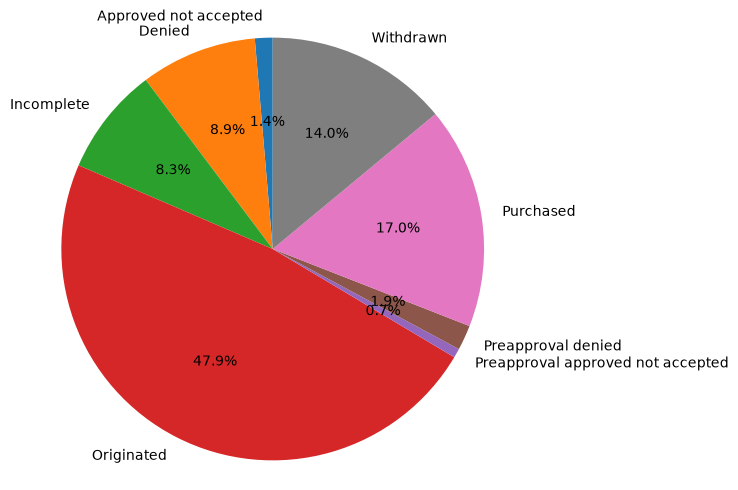

In [10]:
pie_plot(df,'action_taken')

Cash out refinance
(12, 8)


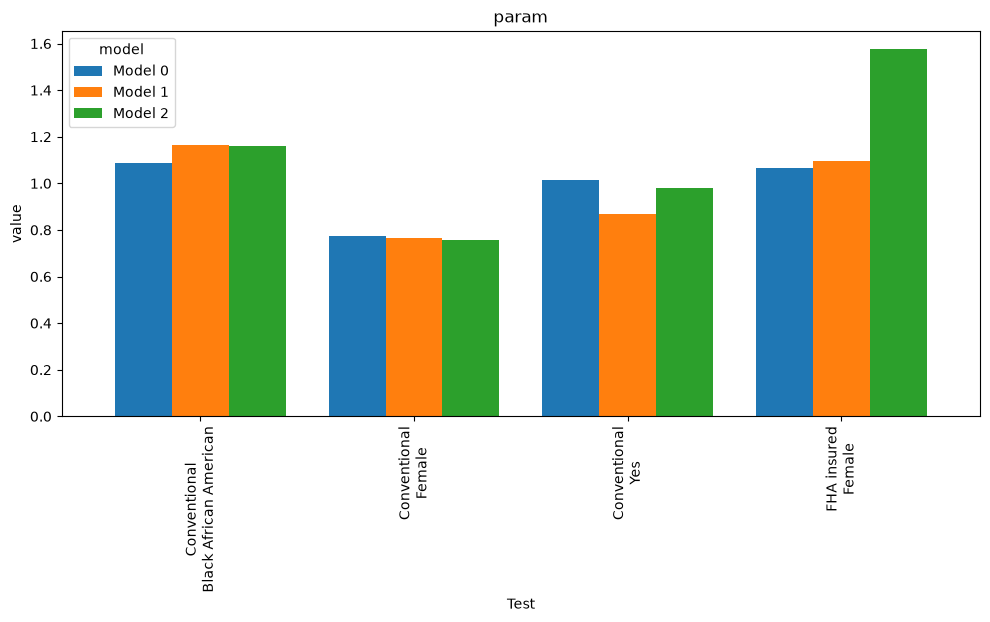

Home purchase
(15, 8)


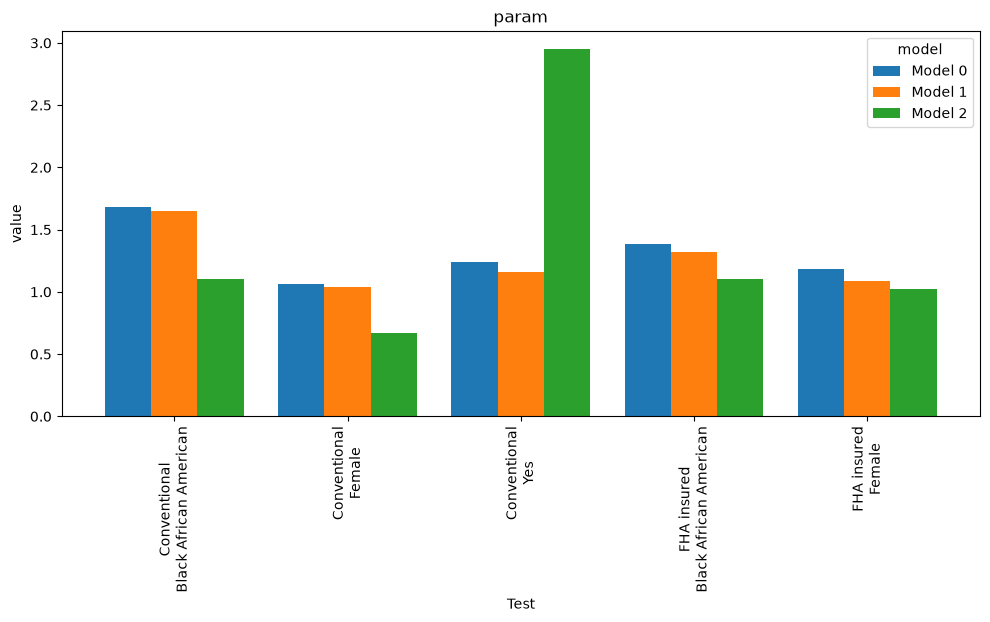

Home improvement
(6, 8)


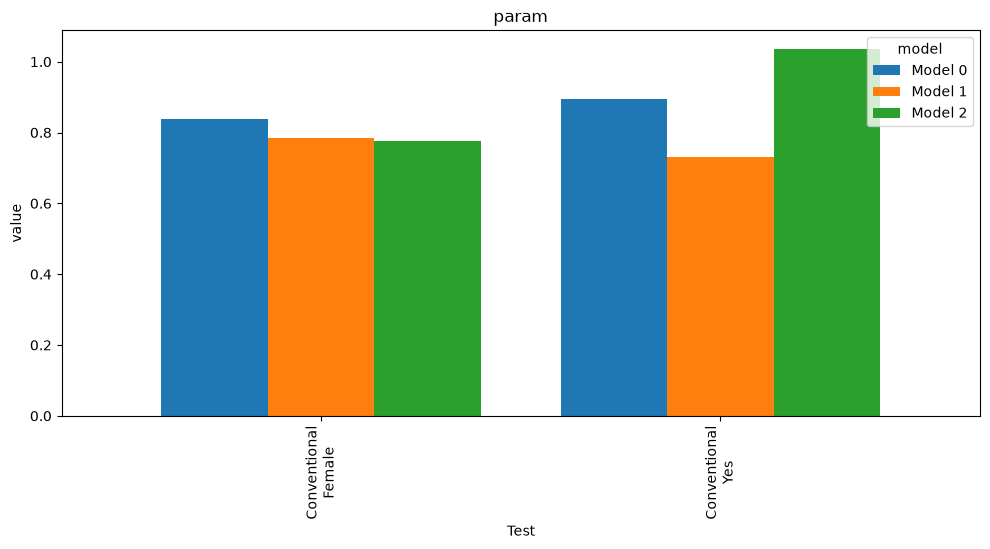

Refinance
(6, 8)


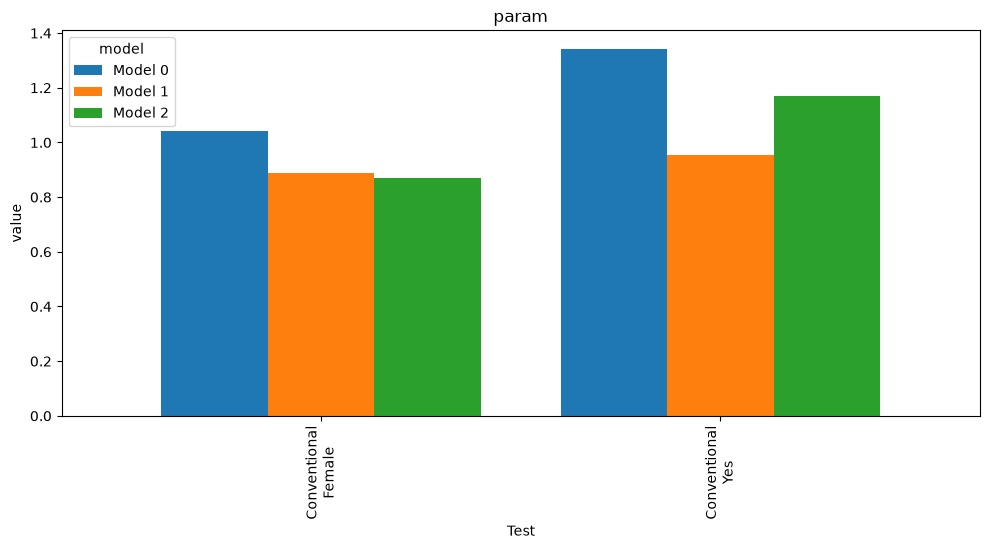

In [11]:
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'param')


    # break

## significance

Cash out refinance
(12, 8)


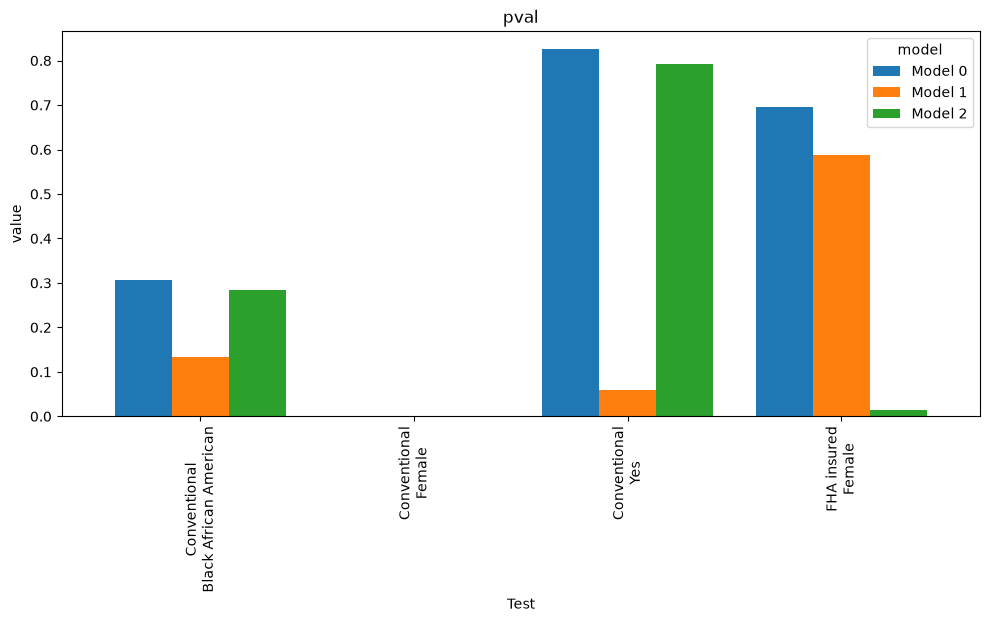

Home purchase
(15, 8)


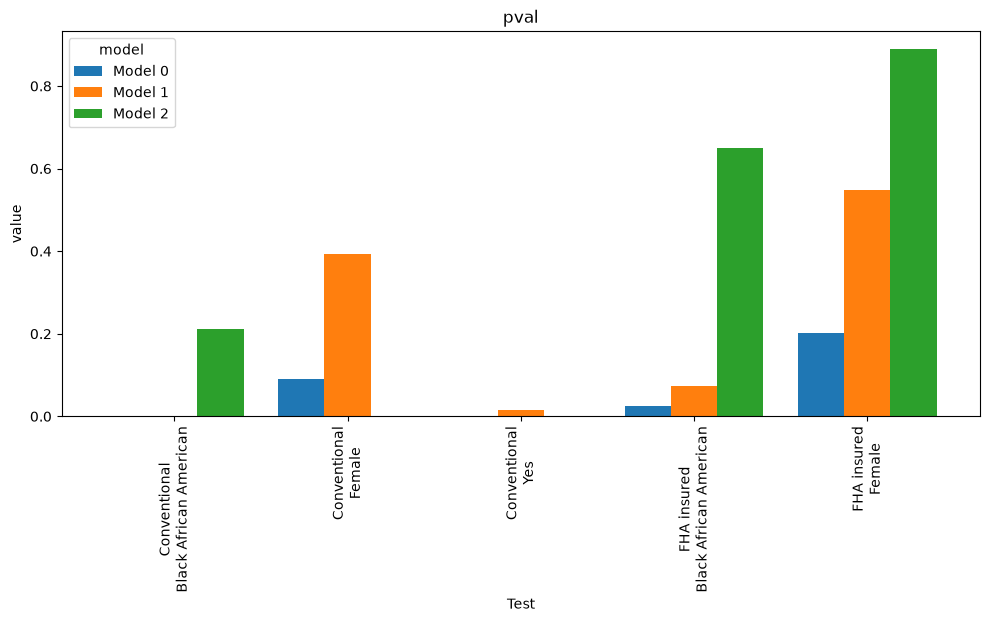

Home improvement
(6, 8)


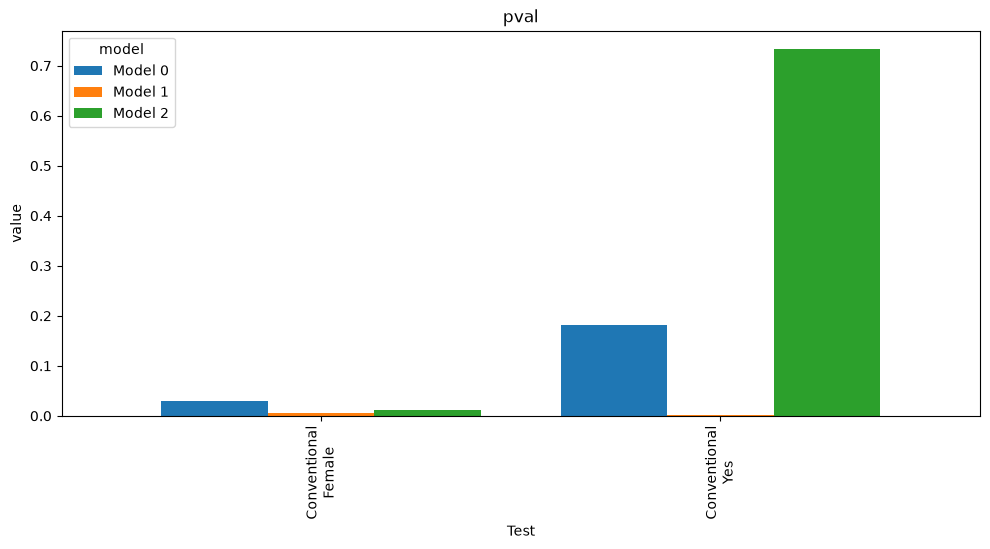

Refinance
(6, 8)


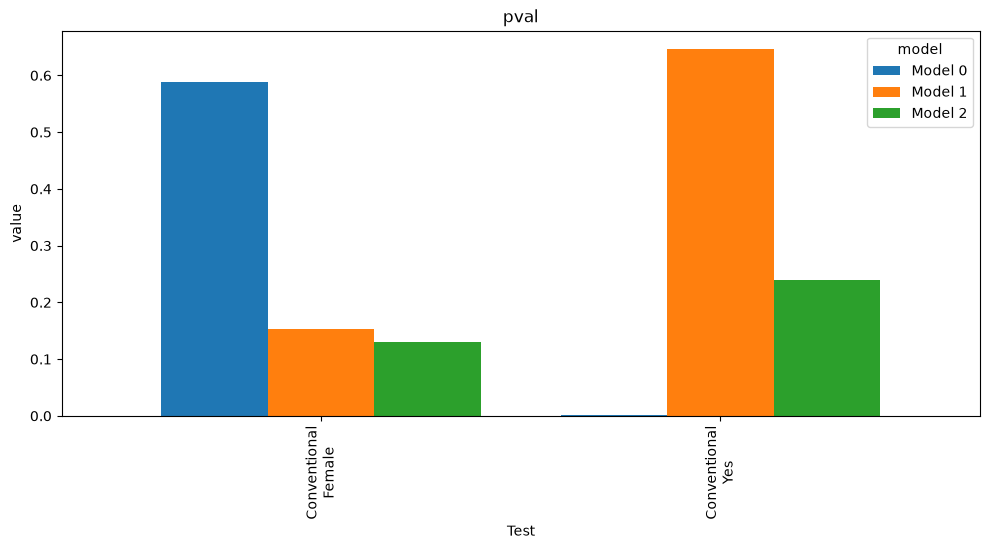

In [12]:
# plot_reg(reg_summary, 'uw', 'pval')
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'pval')


    # break

## model fit

Cash out refinance
(12, 8)


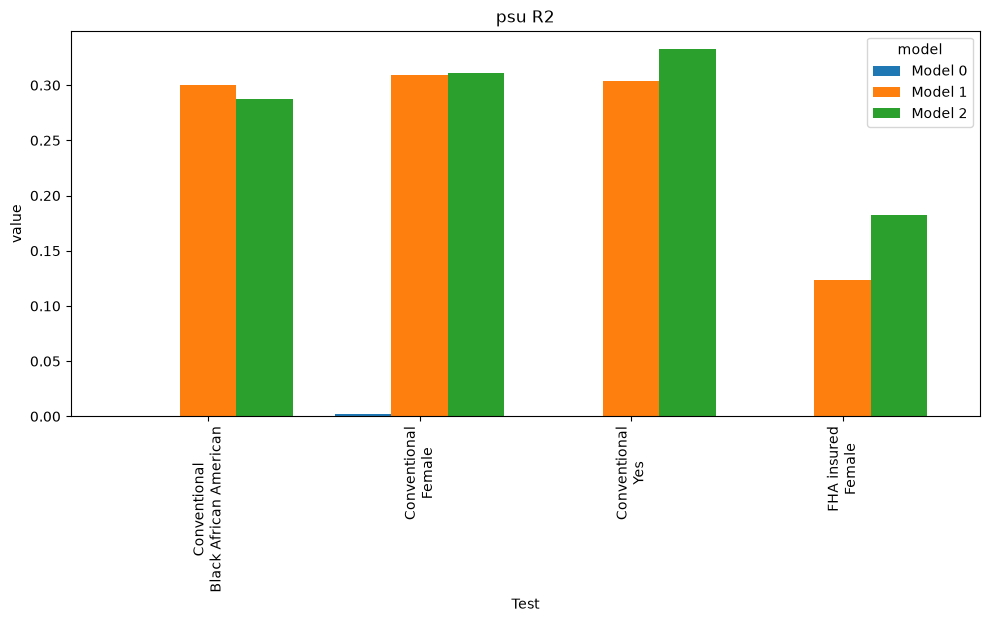

Home purchase
(15, 8)


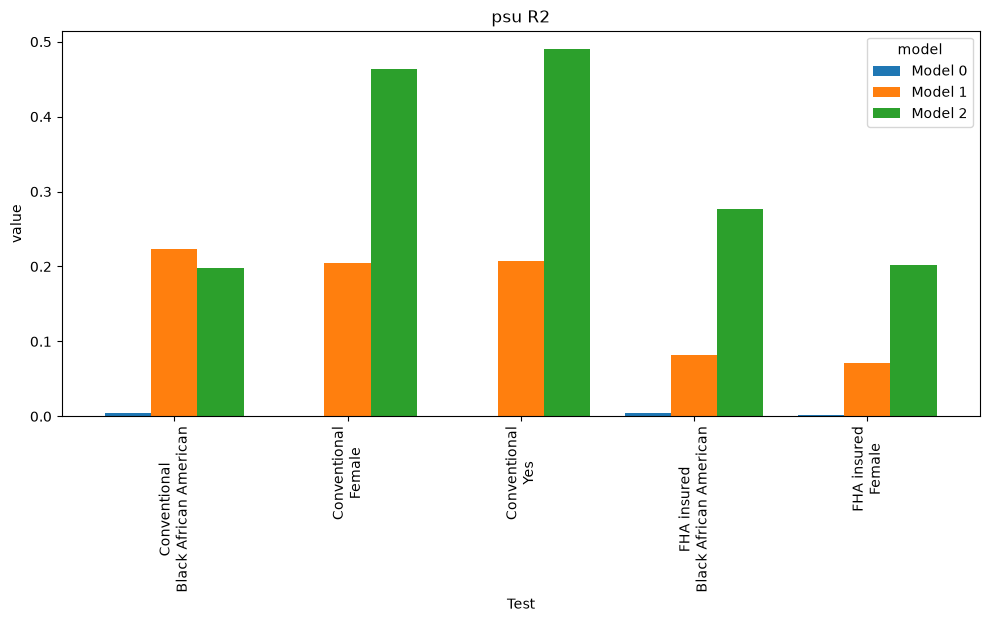

Home improvement
(6, 8)


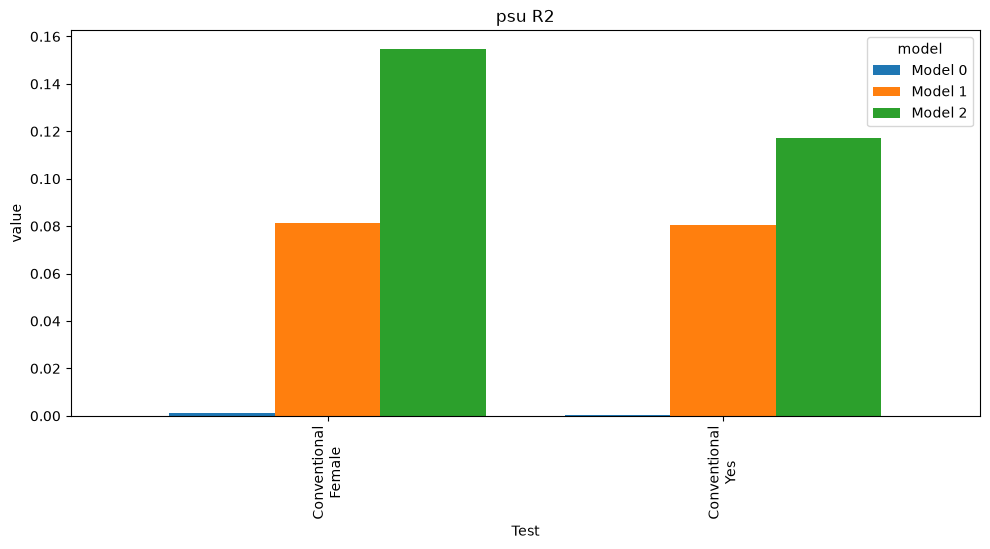

Refinance
(6, 8)


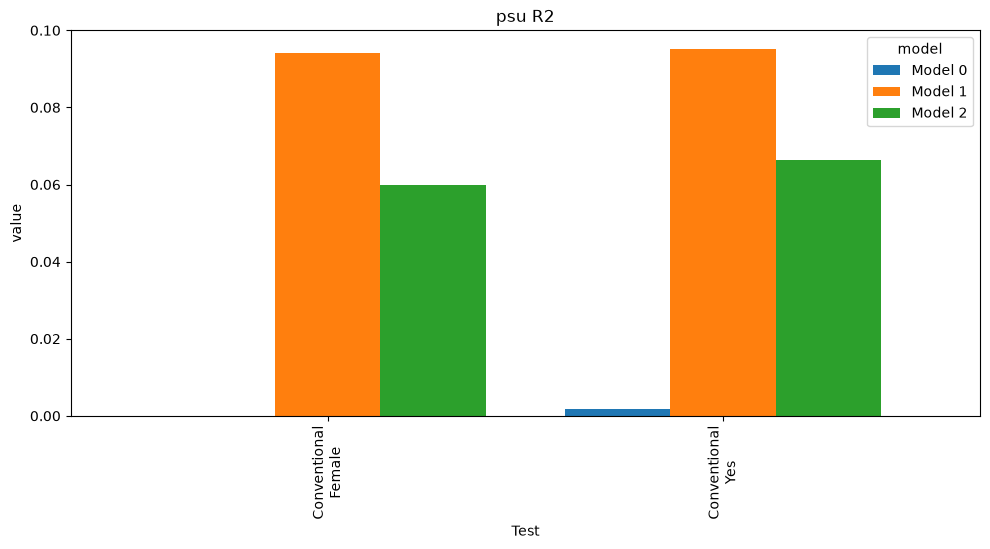

In [13]:
# plot_reg(reg_summary, 'uw', 'psu R2')

for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'psu R2')


    # break

## separation

In [14]:
def plot_separation(
    regs_summary, # reg summary dataframe
    purp, #segment
    step, # uw or price
):
    
    regs_ = reg_summary[
        (reg_summary['loan purpose'] == f'{purp}') &
        (reg_summary.step == f'{step}') &
        reg_summary.model.isin(['Model 1','Model 2'])]#.copy()

    print(regs_.shape)



    import seaborn as sns
    import matplotlib.pyplot as plt
    
    sns.histplot(
        data=regs_,
        x="prediction",
        hue="actual",
        bins=30,
        element="step",
        stat="density",
        common_norm=False
    )
    
    plt.xlabel("Predicted probability")
    plt.ylabel("Density")
    plt.title("Predicted probabilities by actual outcome")
    plt.legend(title="Actual")
    plt.show()

#     loan type	    loan purpose	    step	model	protected basis	        actual	pred	prediction
# 0	Conventional	Cash out refinance	uw	    Model 0	Black African American	0	NaN	        0.195167
# 1	Conventional	Cash out refinance	uw	    Model 0	Black African American	0	NaN	        0.195167
# 2	Conventional	Cash out refinance	uw	    Model 0	Black African American	0	NaN	        0.195167
# 3	Conventional	Cash out refinance	uw	    Model 0	Black African American	0	NaN	        0.195167
# 4	Conventional	Cash out refinance	uw	    Model 0	Black African American	0	NaN	        0.195167

# i want to make plots for the combinations of 



    


Cash out refinance
Conventional
Black African American
Model 1
(7003, 7)


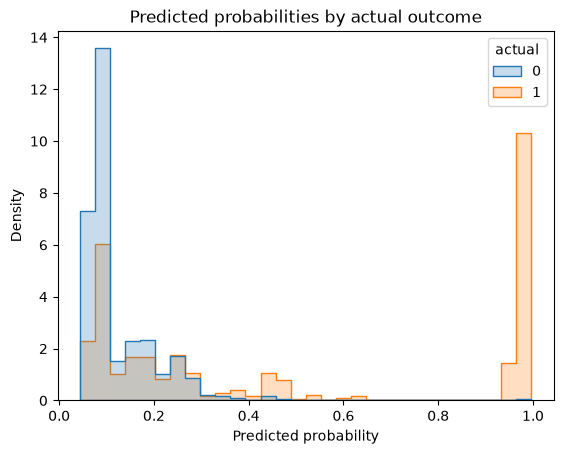

Model 2
(2088, 7)


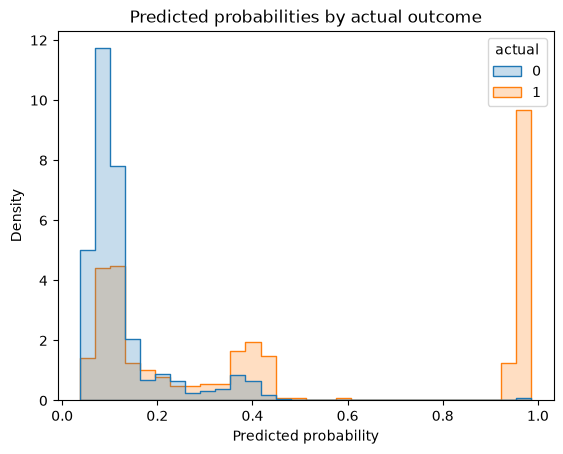

Female
Model 1
(8005, 7)


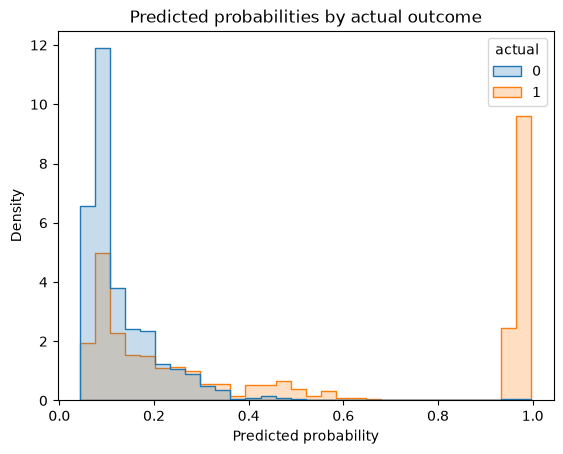

Model 2
(7146, 7)


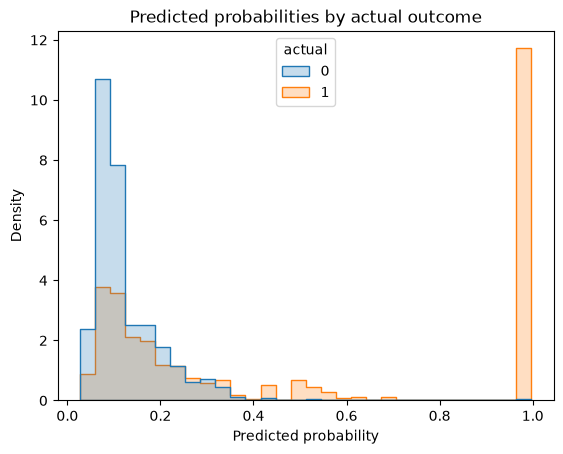

Yes
Model 1
(8347, 7)


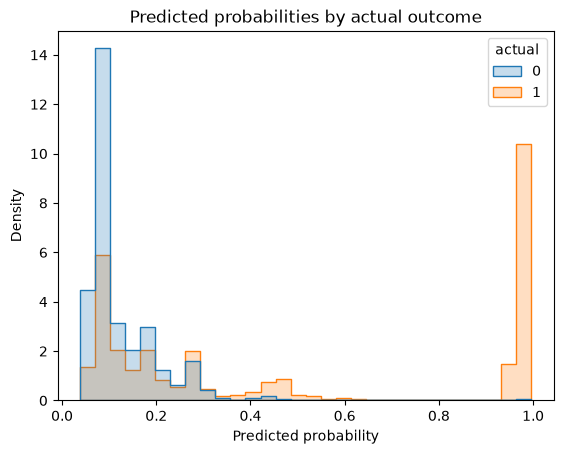

Model 2
(6540, 7)


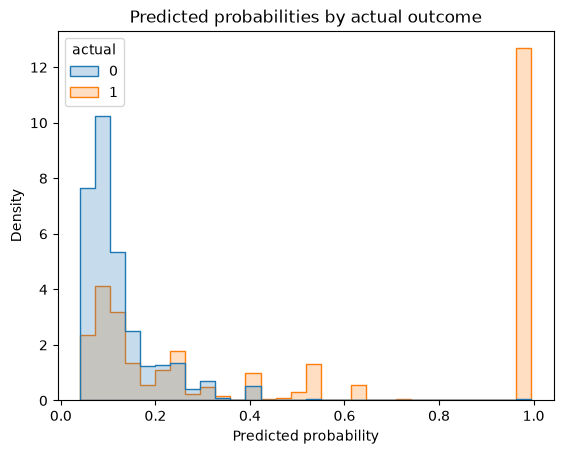

FHA insured
Female
Model 1
(638, 7)


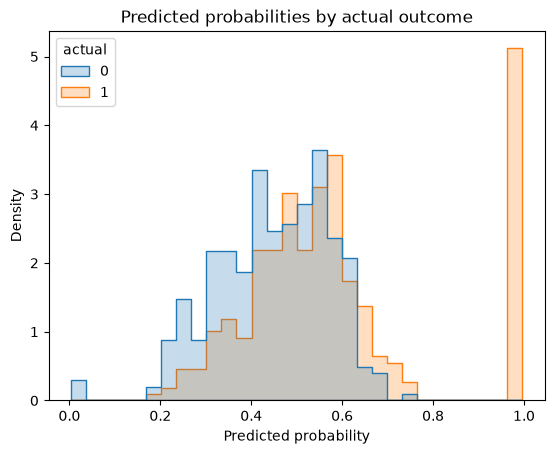

Model 2
(634, 7)


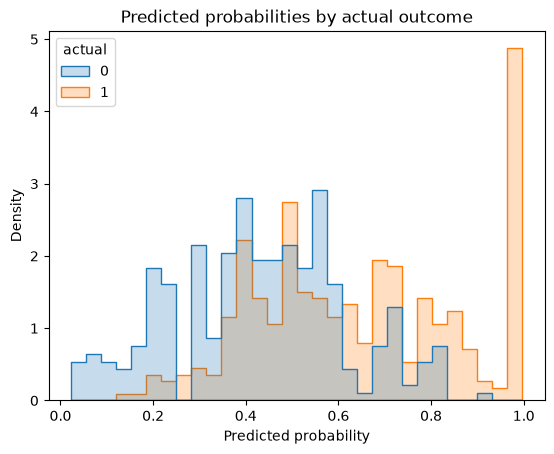


Home purchase
Conventional
Black African American
Model 1
(22542, 7)


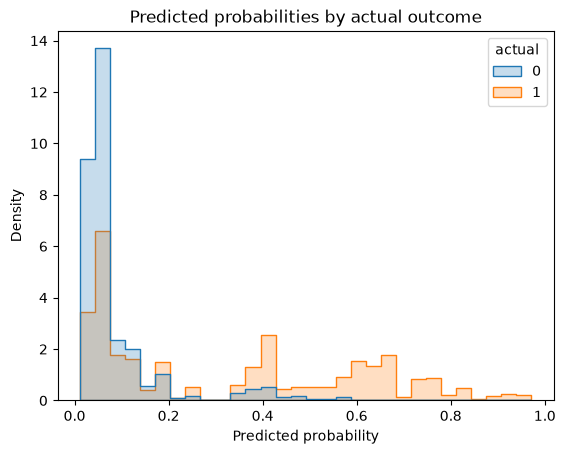

Model 2
(5440, 7)


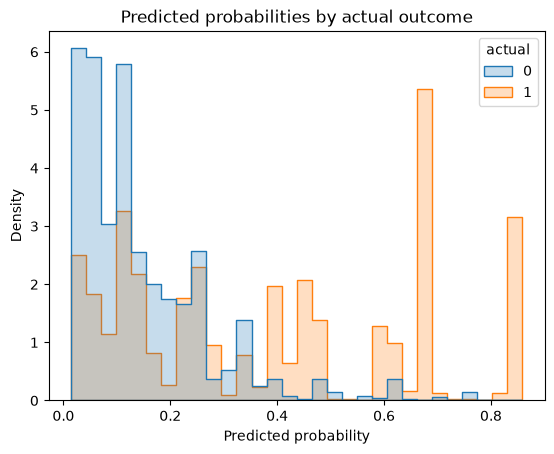

Female
Model 1
(29181, 7)


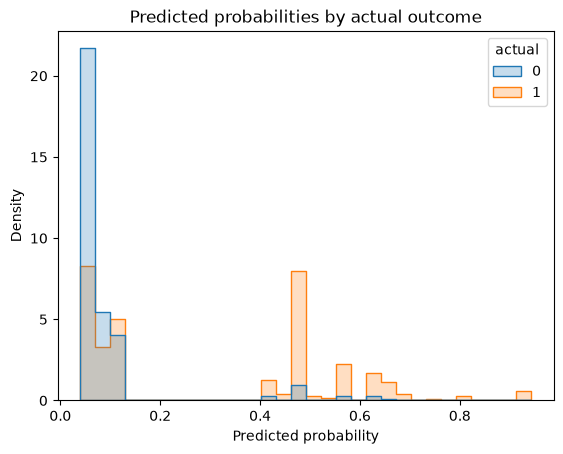

Model 2
(22410, 7)


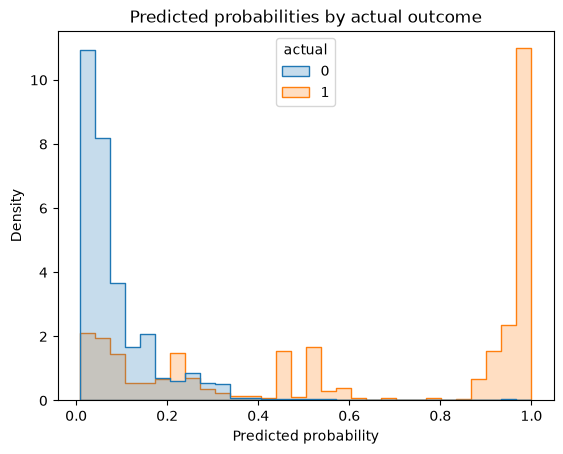

Yes
Model 1
(29877, 7)


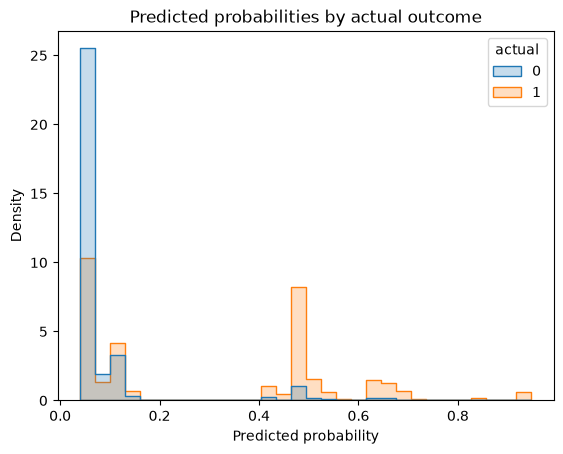

Model 2
(6804, 7)


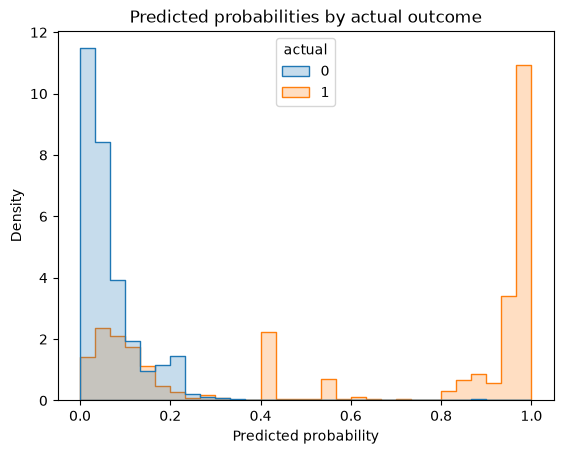

FHA insured
Black African American
Model 1
(909, 7)


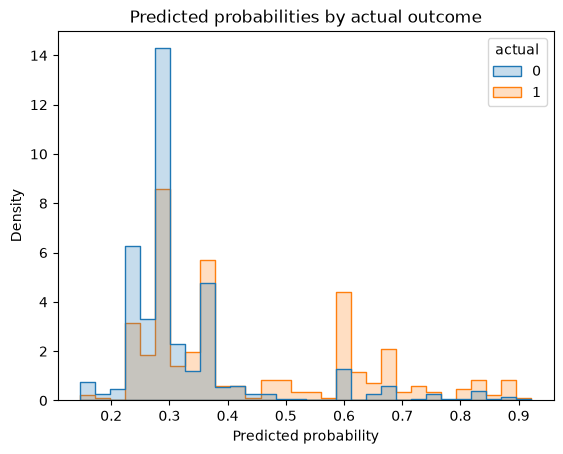

Model 2
(592, 7)


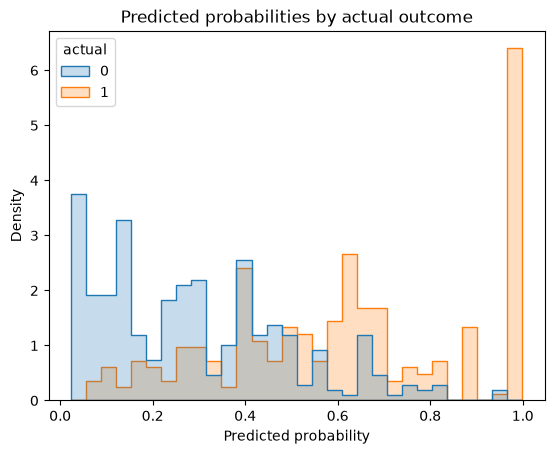

Female
Model 1
(1019, 7)


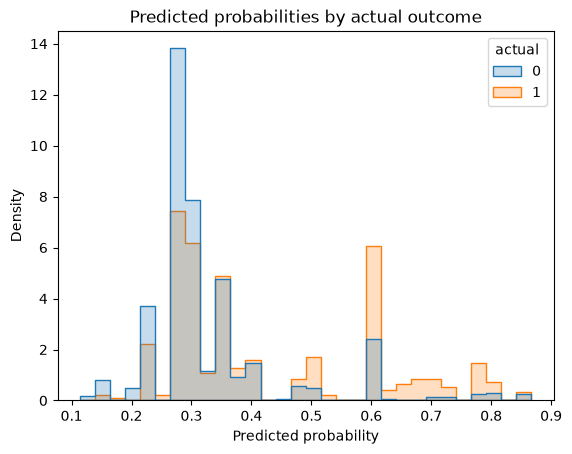

Model 2
(844, 7)


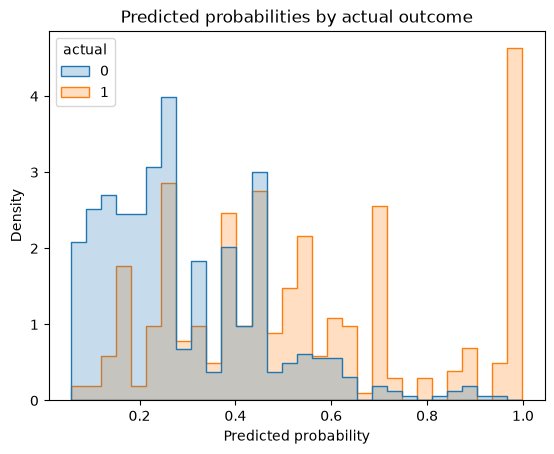


Home improvement
Conventional
Female
Model 1
(3107, 7)


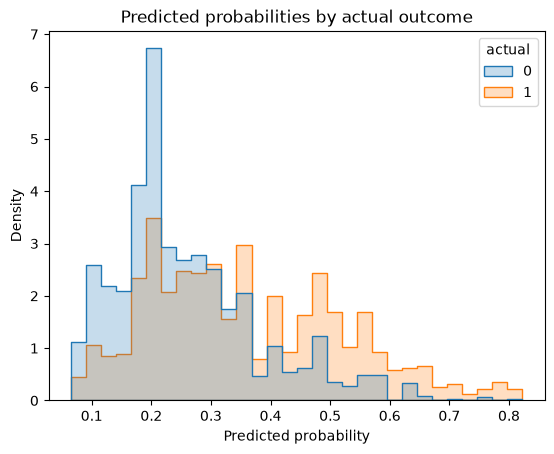

Model 2
(2432, 7)


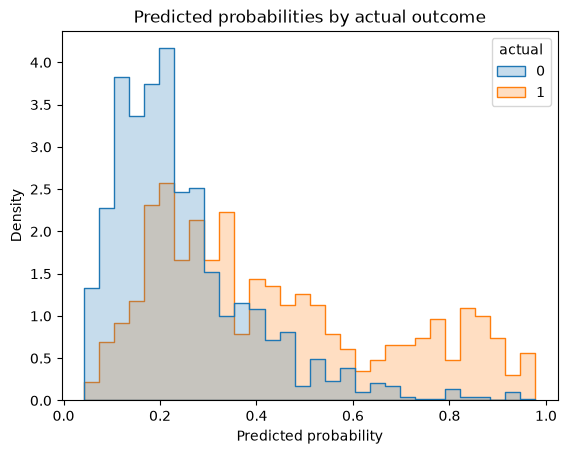

Yes
Model 1
(3160, 7)


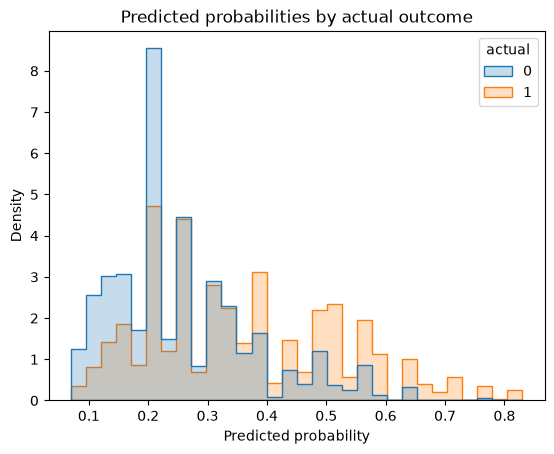

Model 2
(2196, 7)


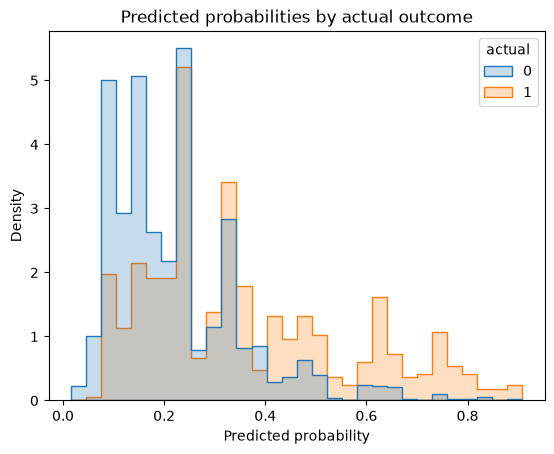


Refinance
Conventional
Female
Model 1
(7038, 7)


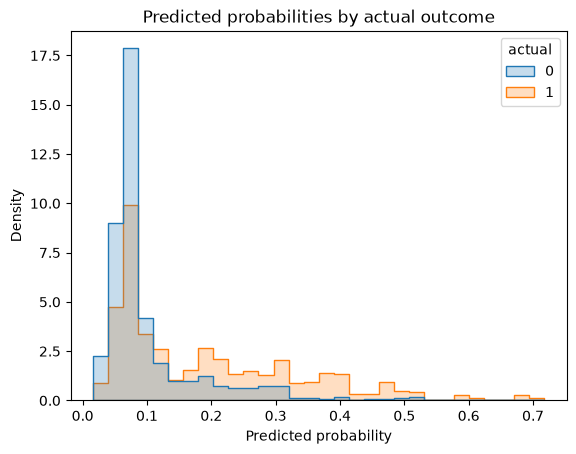

Model 2
(4984, 7)


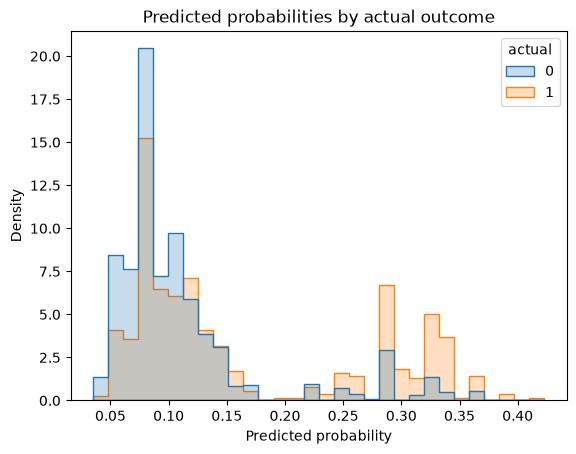

Yes
Model 1
(7186, 7)


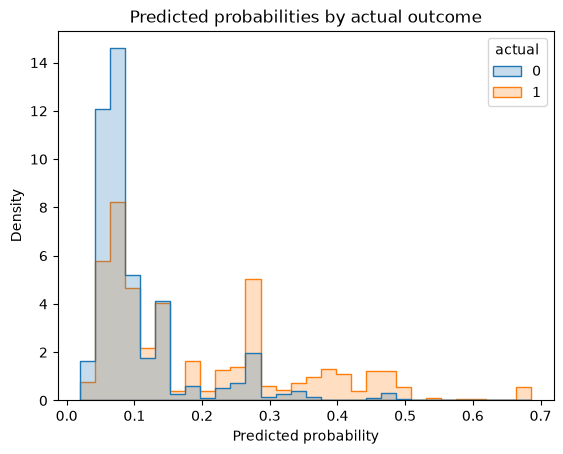

Model 2
(2308, 7)


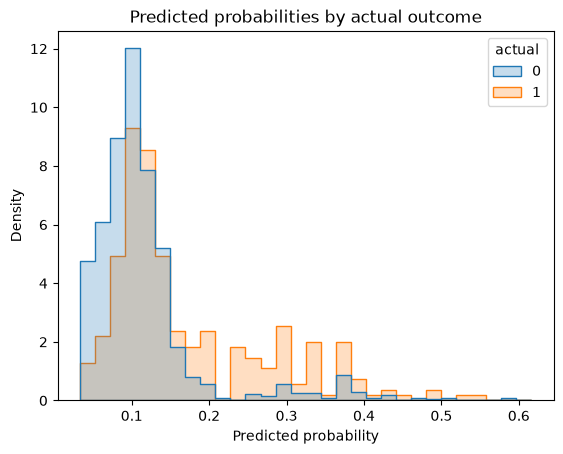

In [15]:


pred_summary = pred_summary[pred_summary['model'].isin(['Model 1','Model 2'])]


for purp_j in pred_summary['loan purpose'].unique().tolist():
    print('')
    print(purp_j)

    # type_list = 
    for type_j in (pred_summary[pred_summary['loan purpose'] == purp_j]['loan type']).unique().tolist():
        # print('')
        print(type_j)

        for pb_j in (pred_summary[
            (pred_summary['loan purpose'] == purp_j) &
            (pred_summary['loan type'] == type_j)
        ]['protected basis']).unique().tolist():
            
            print(pb_j)

            for mod_j in (pred_summary[
                (pred_summary['loan purpose'] == purp_j) &
                (pred_summary['loan type'] == type_j) &
                (pred_summary['protected basis'] == pb_j)
            ]['model']).unique().tolist():
                
                print(mod_j)



            
                pred_ = pred_summary[
                    (pred_summary["loan purpose"] == purp_j)
                    & (pred_summary["loan type"] == type_j)
                    & (pred_summary["step"] == "uw")
                    & (pred_summary["model"] ==  mod_j)
                    & (pred_summary['protected basis'] == pb_j)
                ]
        
            
                print(pred_.shape)

                import seaborn as sns
                import matplotlib.pyplot as plt
                
                ax = sns.histplot(
                    data=pred_,
                    x="prediction",
                    hue="actual",
                    bins=30,
                    element="step",
                    stat="density",
                    common_norm=False
                )
                
                ax.set_xlabel("Predicted probability")
                ax.set_ylabel("Density")
                ax.set_title("Predicted probabilities by actual outcome")
                plt.show()






                

                # break # model_j    
            # break #pb_j
    #     break#type_j
    # break#purp_j


Cash out refinance
Conventional
Black African American
(9091, 7)


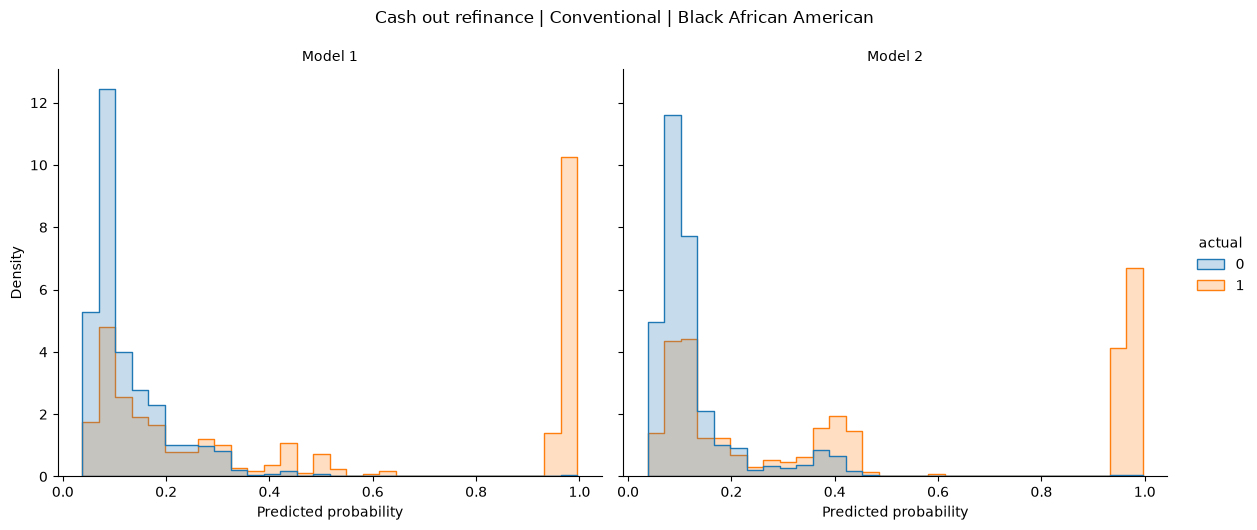

Female
(15151, 7)


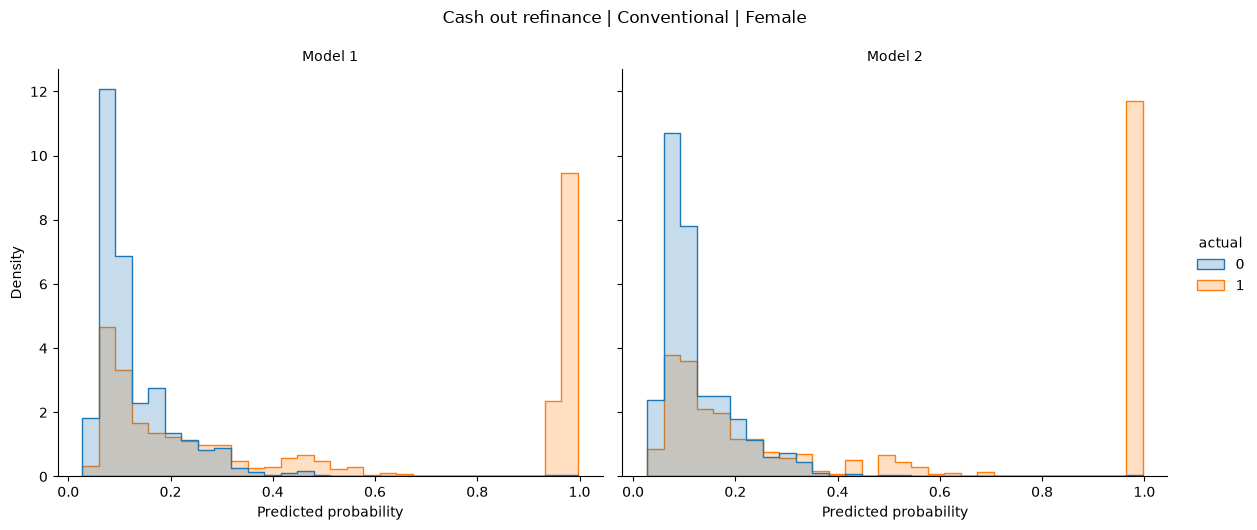

Yes
(14887, 7)


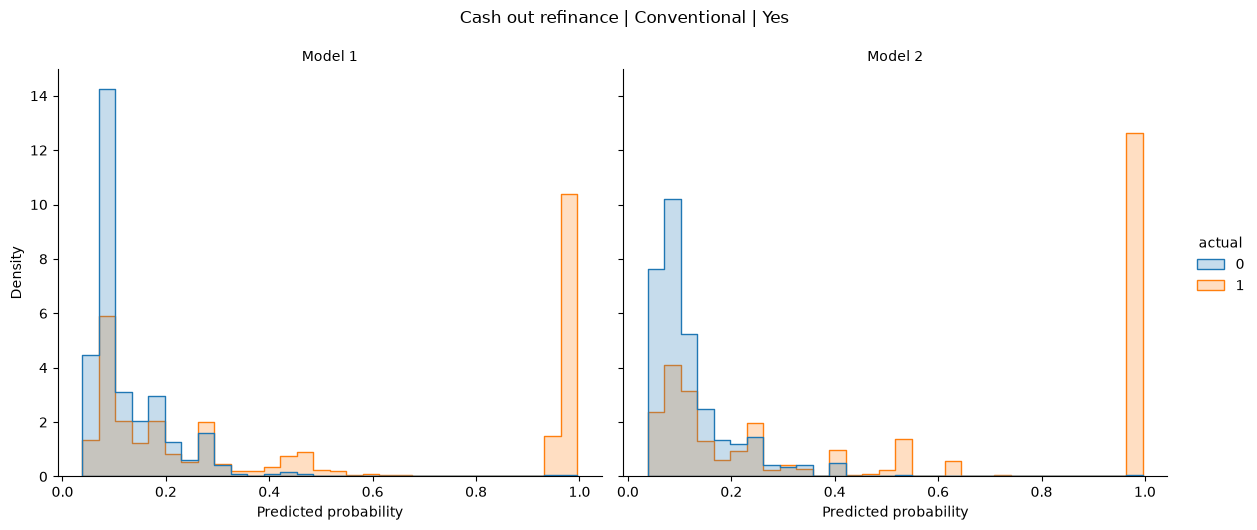

FHA insured
Female
(1272, 7)


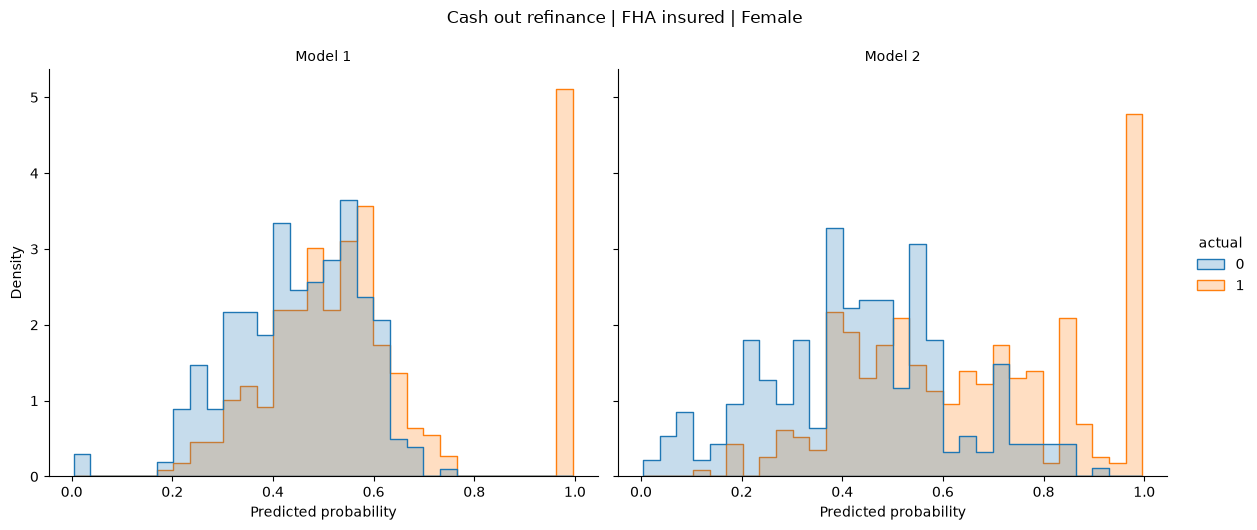


Home purchase
Conventional
Black African American
(27982, 7)


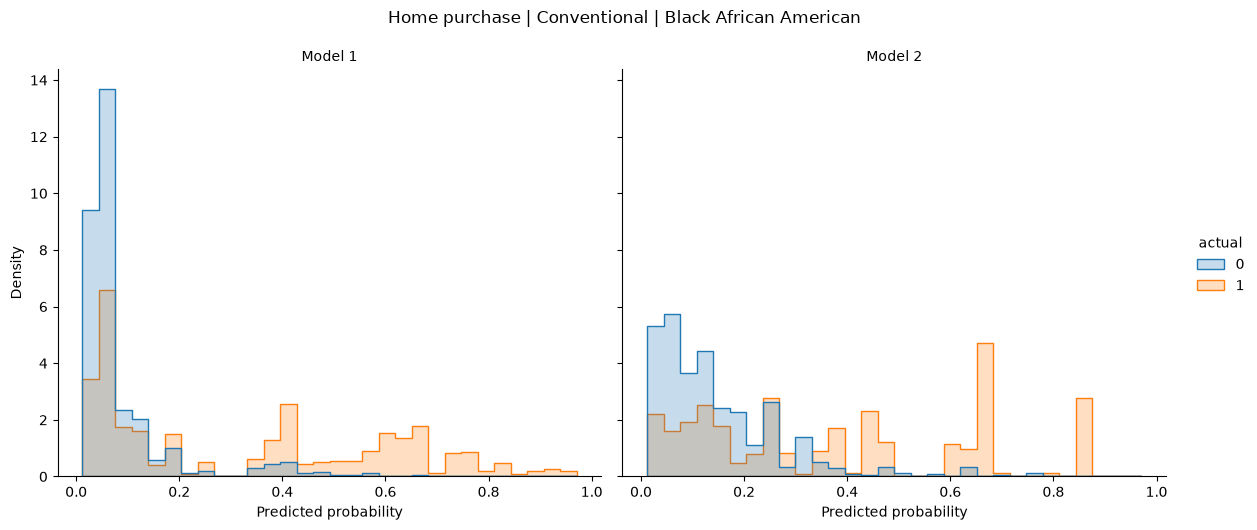

Female
(51591, 7)


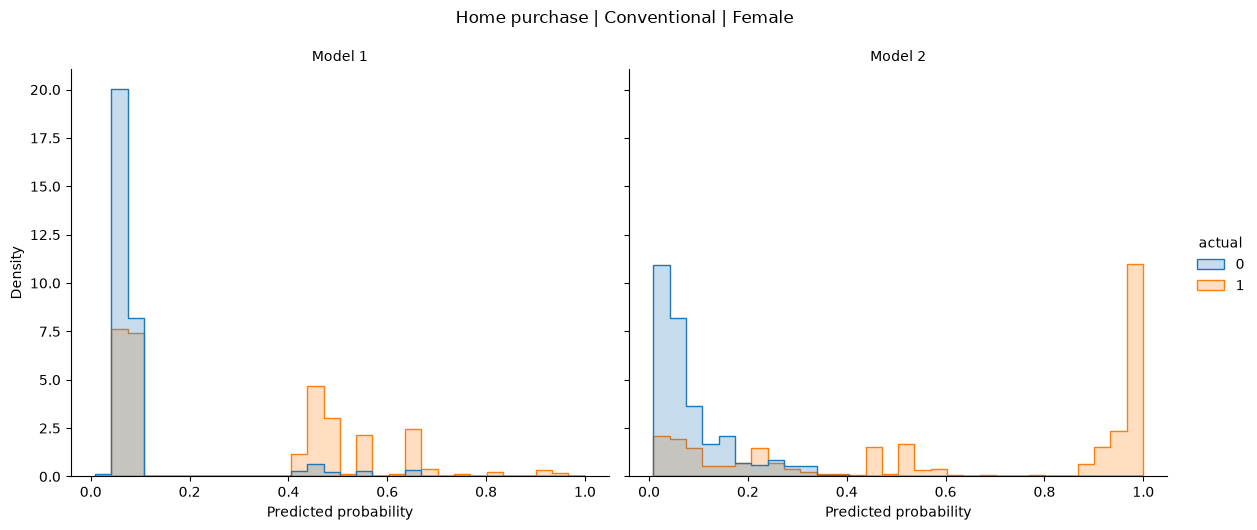

Yes
(36681, 7)


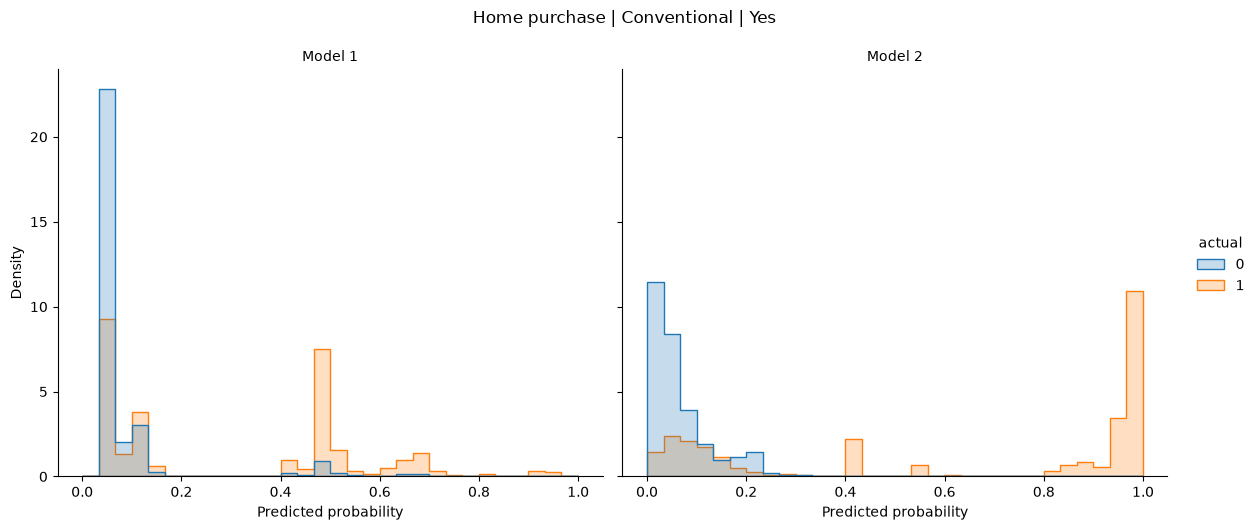

FHA insured
Black African American
(1501, 7)


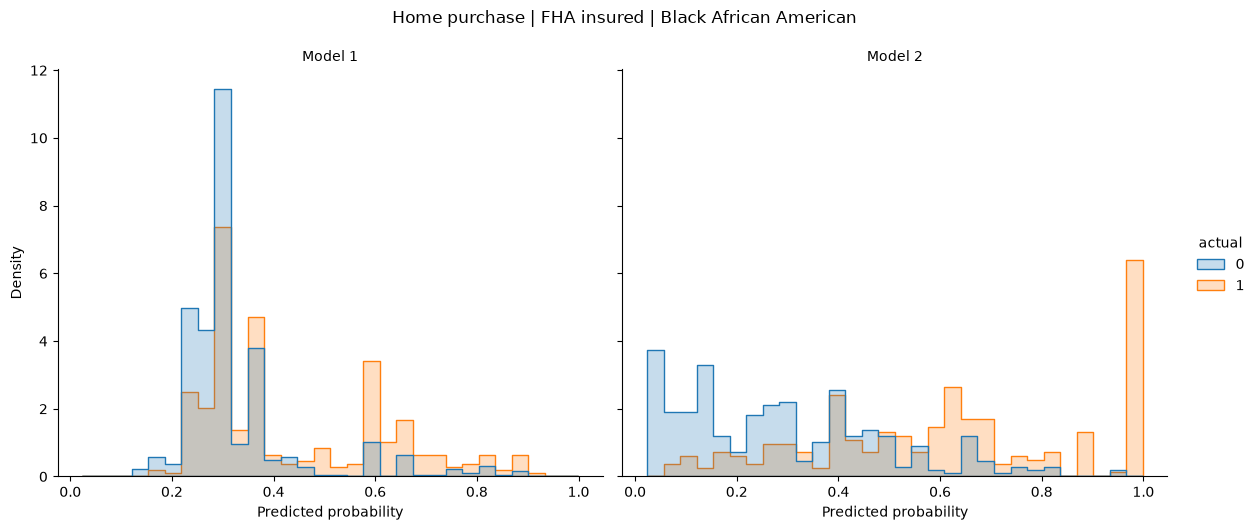

Female
(1863, 7)


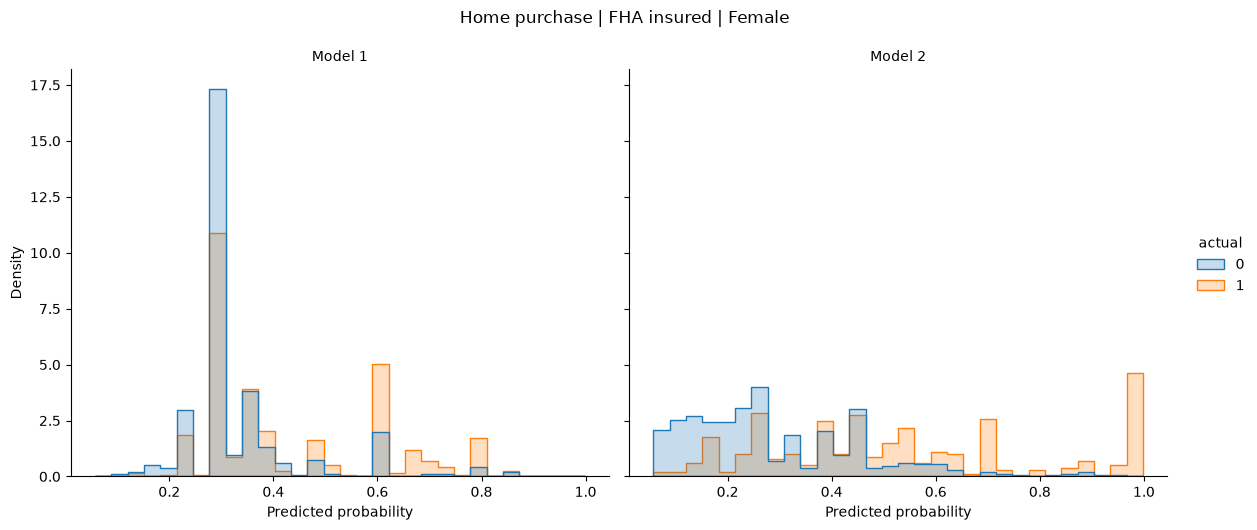


Home improvement
Conventional
Female
(5539, 7)


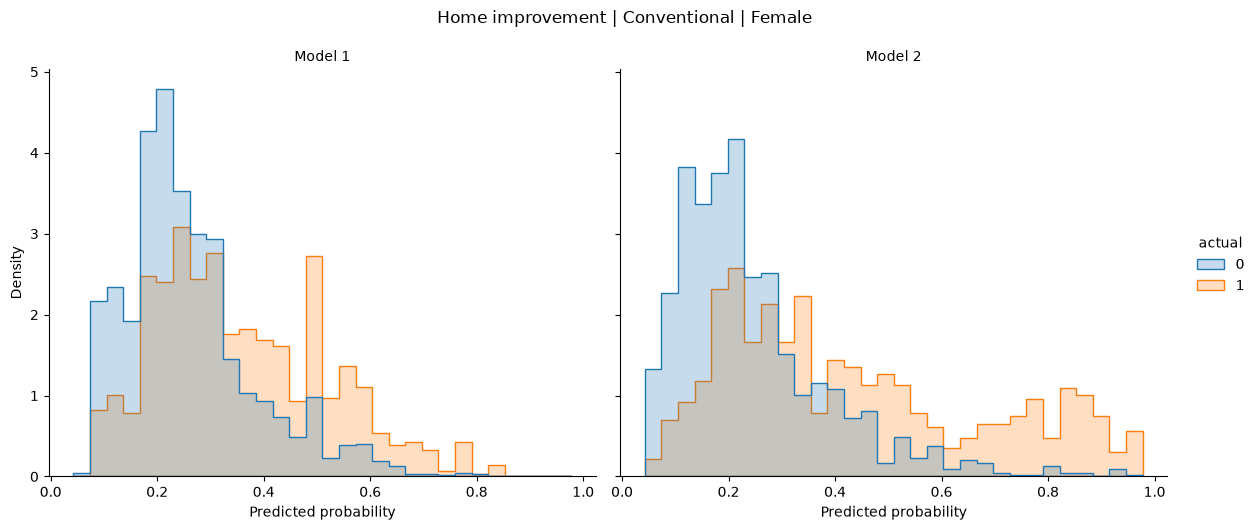

Yes
(5356, 7)


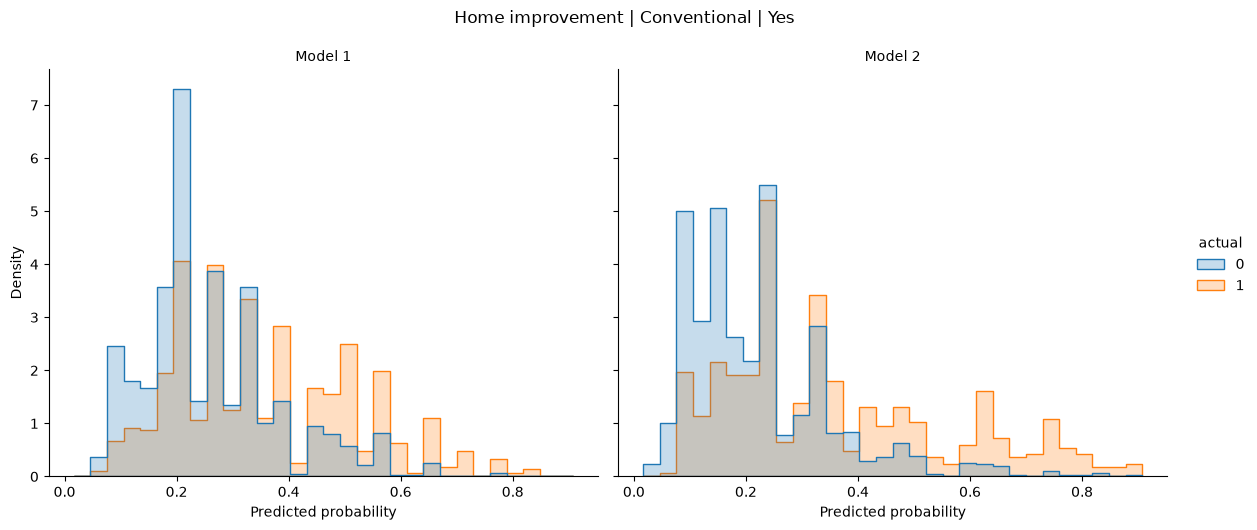


Refinance
Conventional
Female
(12022, 7)


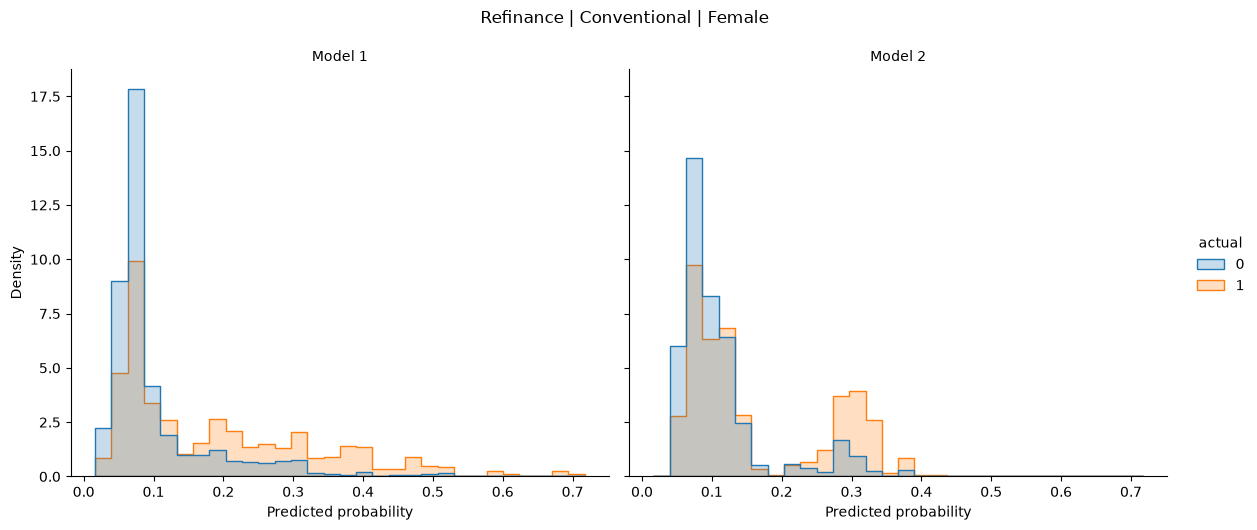

Yes
(9494, 7)


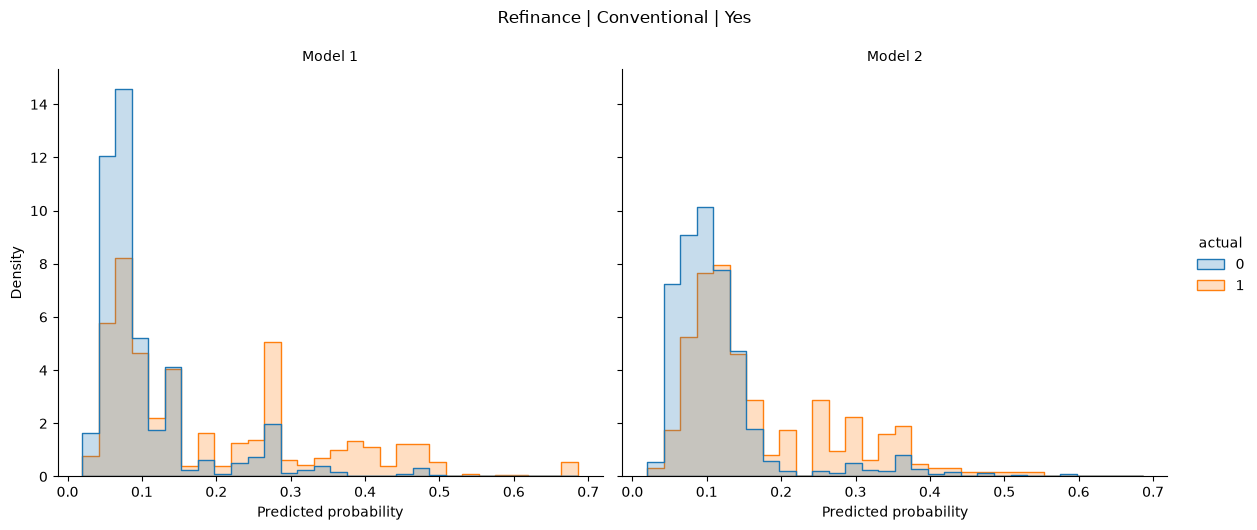

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only the models of interest
pred_summary = pred_summary[
    pred_summary["model"].isin(["Model 1", "Model 2"])
].copy()

for purp_j in pred_summary["loan purpose"].dropna().unique():
    print(f"\n{purp_j}")

    for type_j in pred_summary.loc[
        pred_summary["loan purpose"] == purp_j,
        "loan type"
    ].dropna().unique():

        print(type_j)

        for pb_j in pred_summary.loc[
            (pred_summary["loan purpose"] == purp_j)
            & (pred_summary["loan type"] == type_j),
            "protected basis"
        ].dropna().unique():

            print(pb_j)

            # Select both models at once
            pred_ = pred_summary[
                (pred_summary["loan purpose"] == purp_j)
                & (pred_summary["loan type"] == type_j)
                & (pred_summary["step"] == "uw")
                & (pred_summary["protected basis"] == pb_j)
                & (pred_summary["model"].isin(["Model 1", "Model 2"]))
            ].dropna(subset=["prediction", "actual"])

            print(pred_.shape)

            # Two side-by-side plots: one for each model
            g = sns.displot(
                data=pred_,
                x="prediction",
                hue="actual",
                col="model",
                col_order=["Model 1", "Model 2"],
                bins=30,
                element="step",
                stat="density",
                common_norm=False,
                height=5,
                aspect=1.2
            )

            g.set_axis_labels(
                "Predicted probability",
                "Density"
            )

            g.set_titles("{col_name}")

            g.figure.suptitle(
                f"{purp_j} | {type_j} | {pb_j}",
                y=1.05
            )

            plt.show()


In [17]:
pred_.head()

,loan type,loan purpose,step,model,protected basis,actual,prediction
188808,Conventional,Refinance,uw,Model 1,Yes,0,0.066803
188809,Conventional,Refinance,uw,Model 1,Yes,0,0.083678
188810,Conventional,Refinance,uw,Model 1,Yes,0,0.047674
188811,Conventional,Refinance,uw,Model 1,Yes,0,0.460155
188812,Conventional,Refinance,uw,Model 1,Yes,0,0.118278


# pricing

In [18]:
df = df[df.reg_price == 1]

## Analysis Highlights

- In general effect of PB on interest rate remains similar across model 1 and 2.
- While magnitudes don't change much, significance of effect changed across model 1 and 2 in about half of the tests.
- Model fit across most tests improved across models 1 and 2 with few exceptions.


While magnitude of coefficients doesn't change much identifying potential areas of risk also depends on significance. There is likely to have been a different outcome in identifying potential risk for these test under model 1, supporting the value add of incorporating PSA into analysis.

## effect

<Axes: >

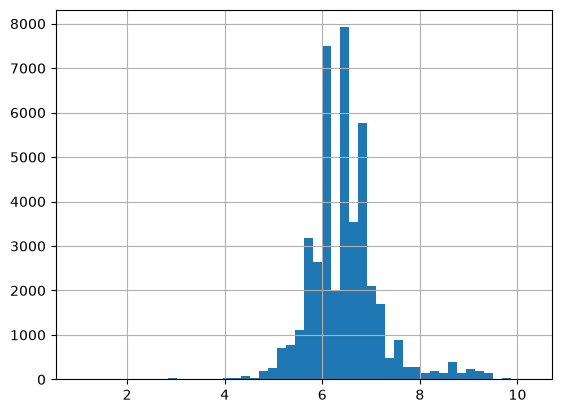

In [19]:
df[df.interest_rate != -9999].interest_rate.hist(bins = 50)

Cash out refinance
(12, 8)


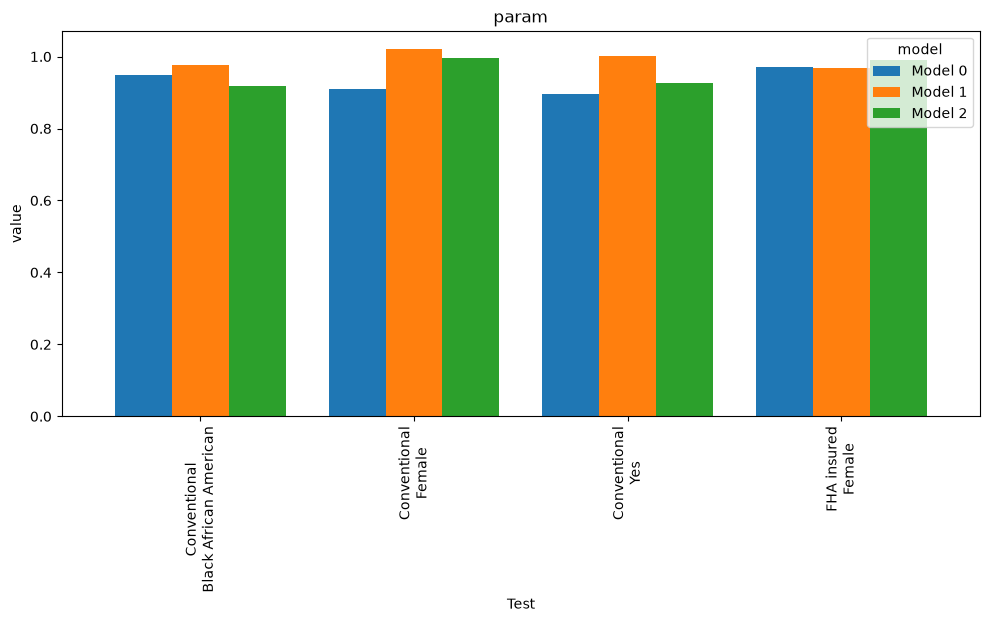

Home purchase
(15, 8)


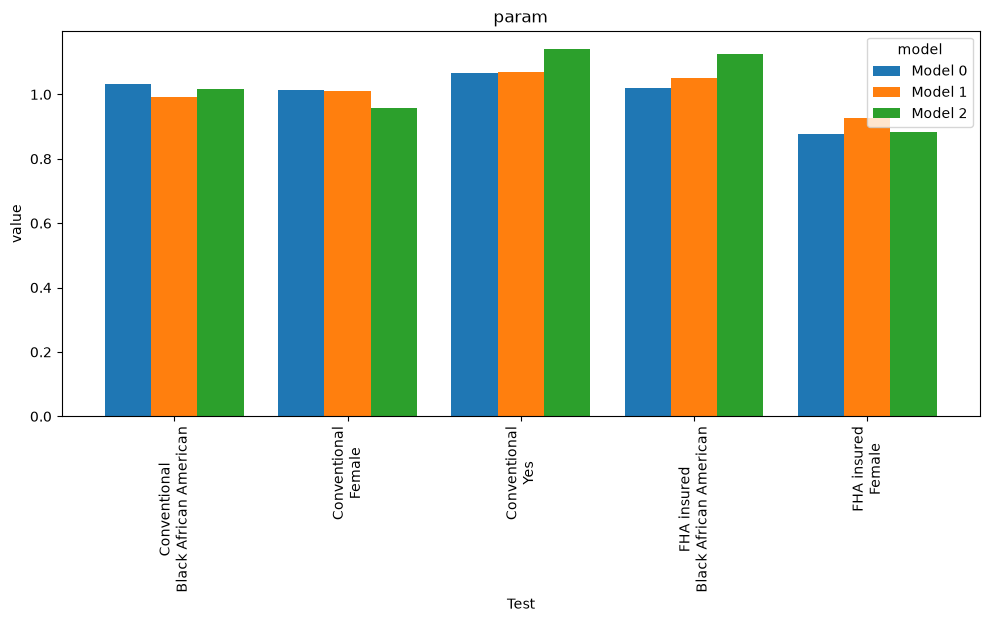

Home improvement
(6, 8)


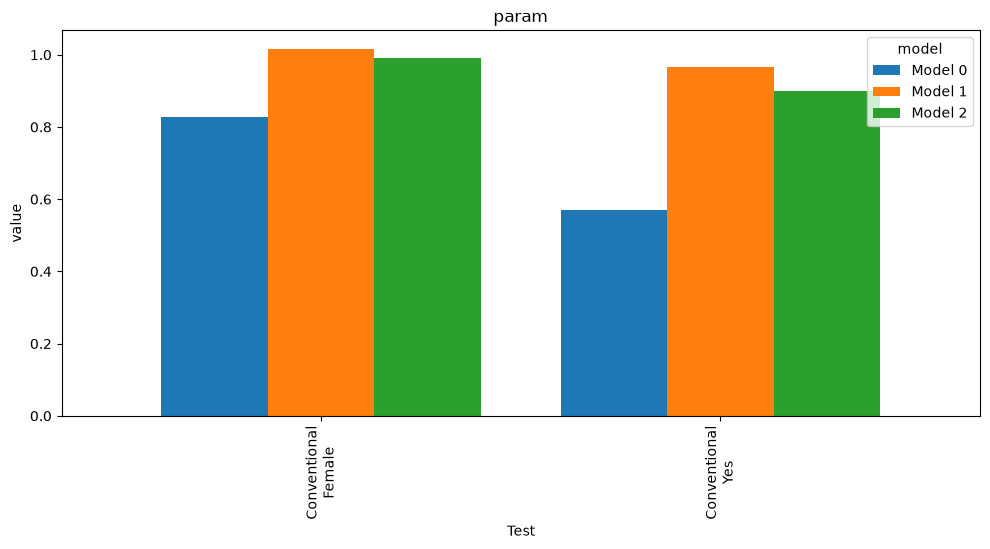

Refinance
(6, 8)


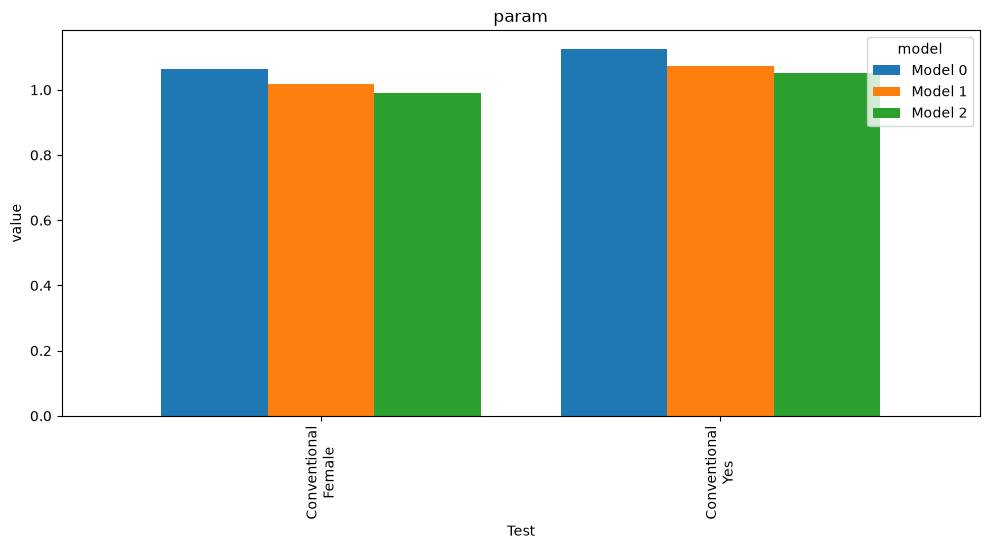

In [20]:
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'param')


    # break

## significance

Cash out refinance
(12, 8)


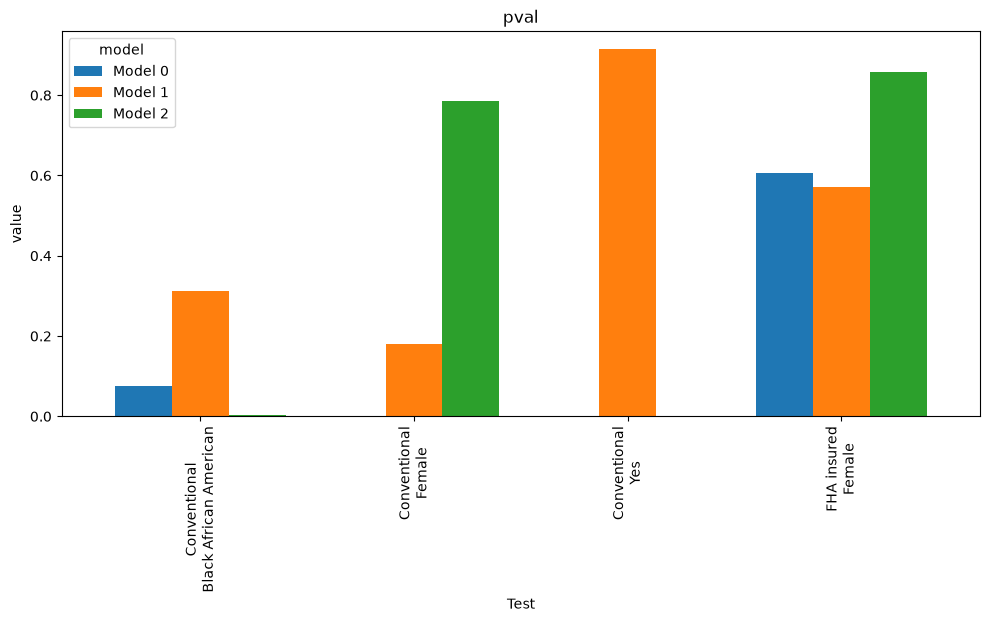

Home purchase
(15, 8)


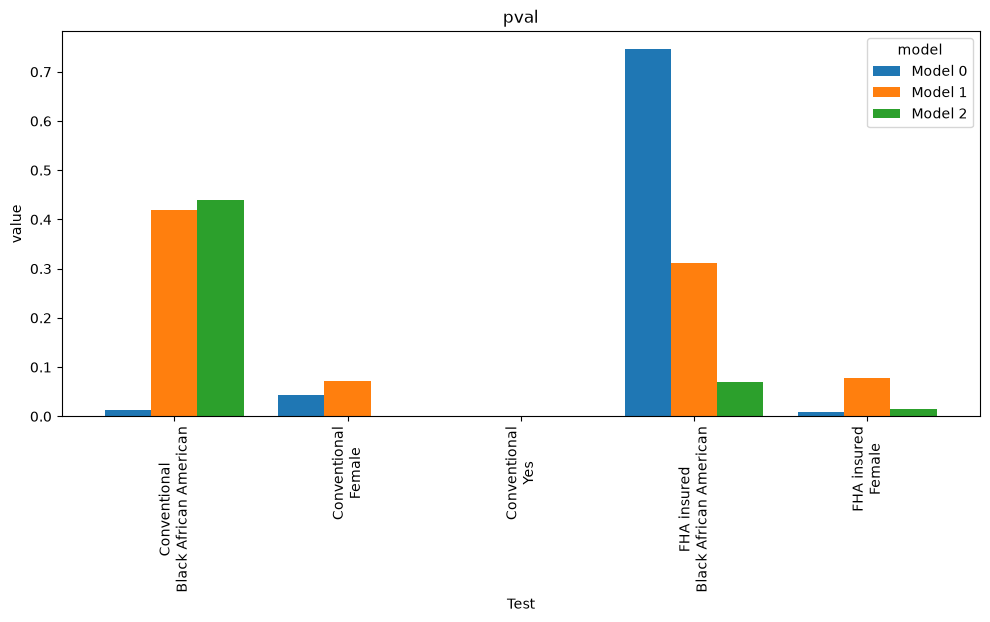

Home improvement
(6, 8)


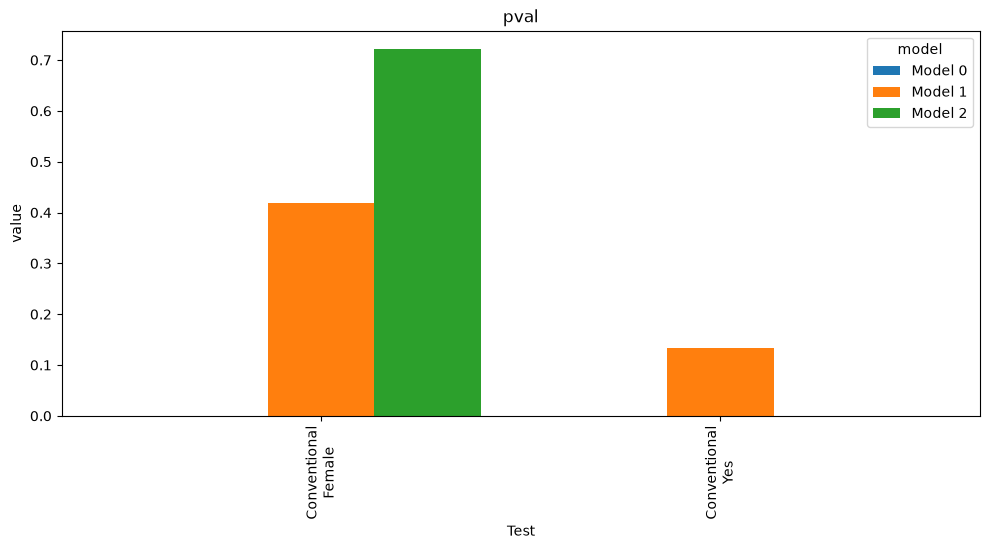

Refinance
(6, 8)


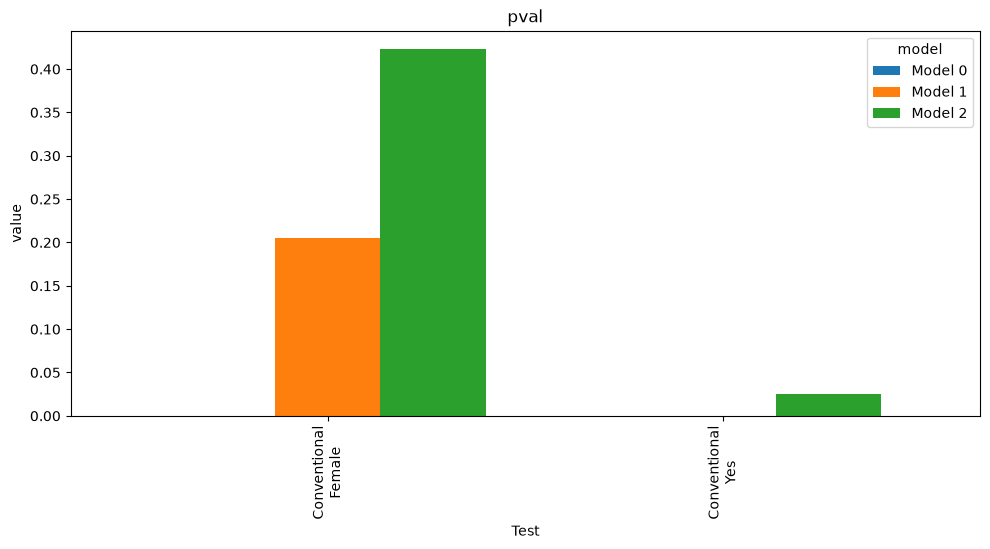

In [21]:
# plot_reg(reg_summary, 'uw', 'pval')
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'pval')


    # break

## model fit

Cash out refinance
(12, 8)


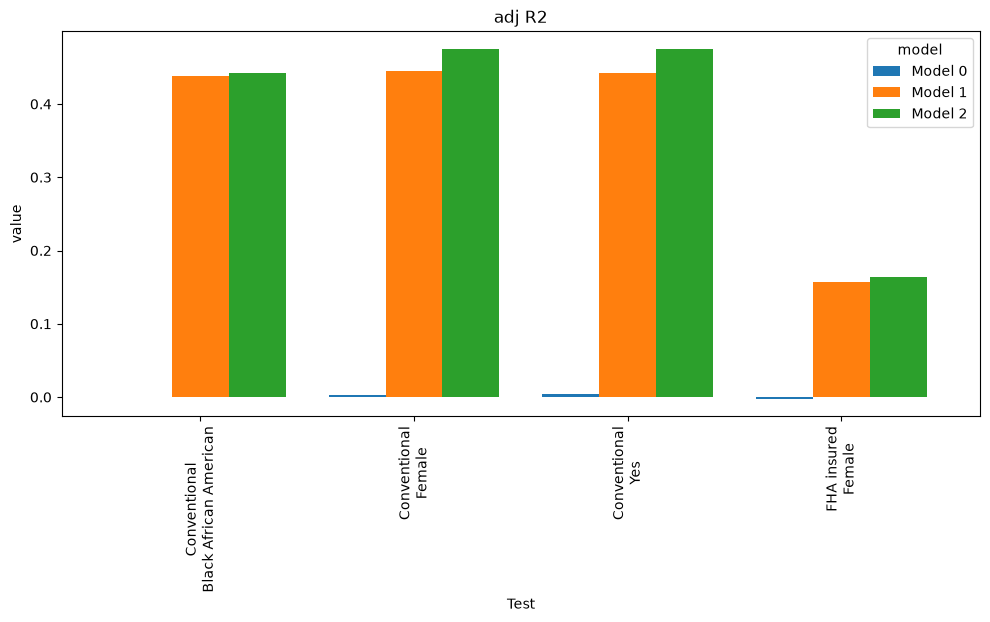

Home purchase
(15, 8)


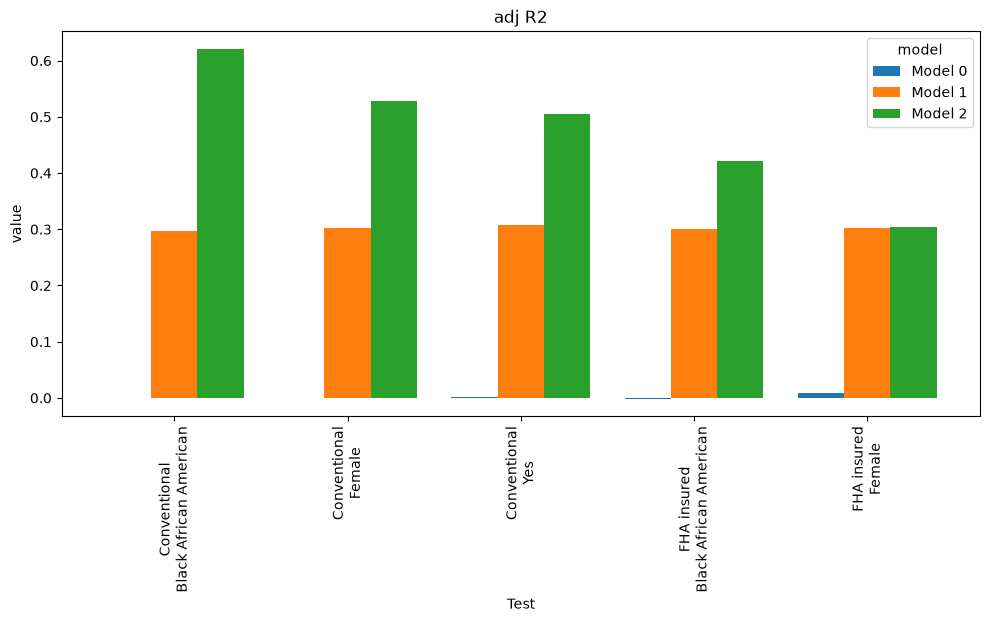

Home improvement
(6, 8)


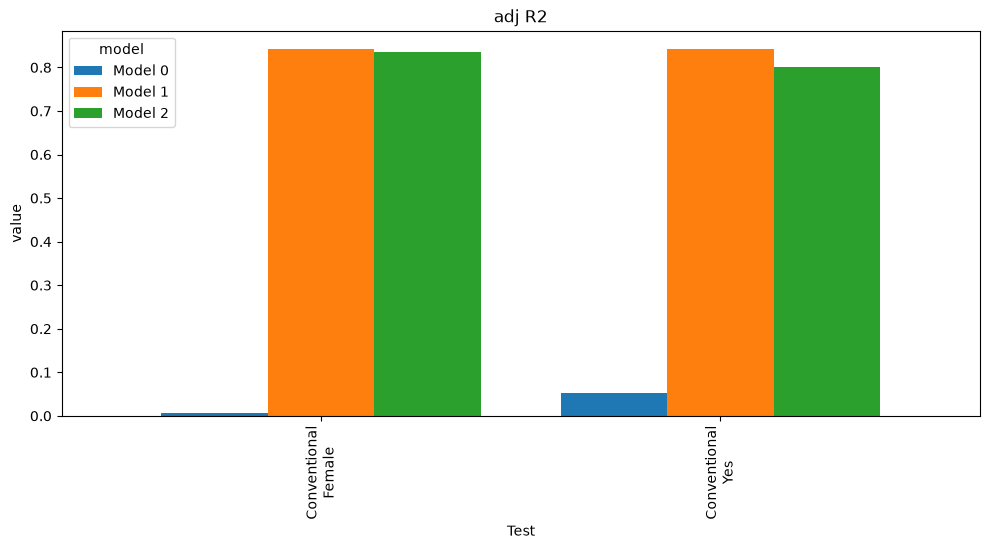

Refinance
(6, 8)


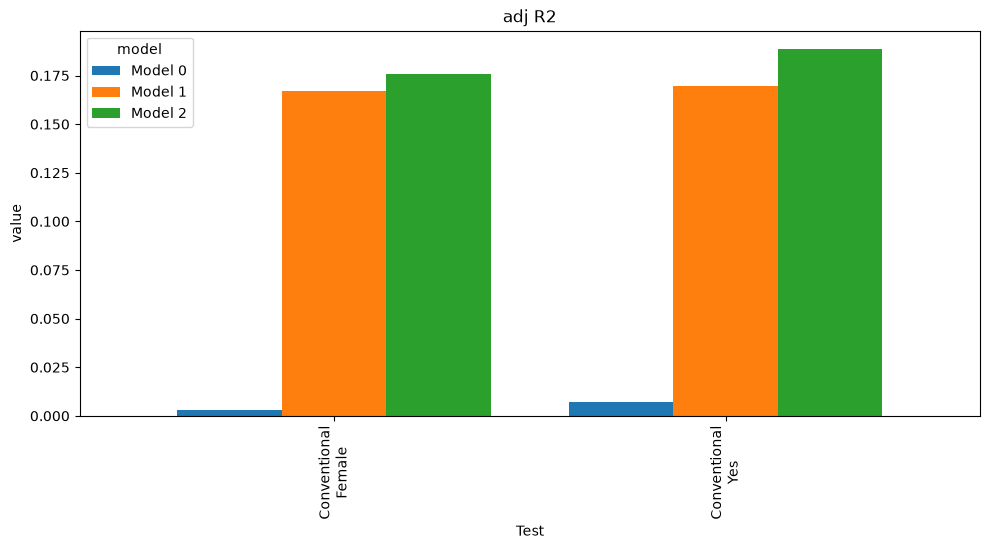

In [22]:
# plot_reg(reg_summary, 'uw', 'psu R2')

for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'adj R2')


    # break


Cash out refinance
Conventional
Black African American
(7274, 7)


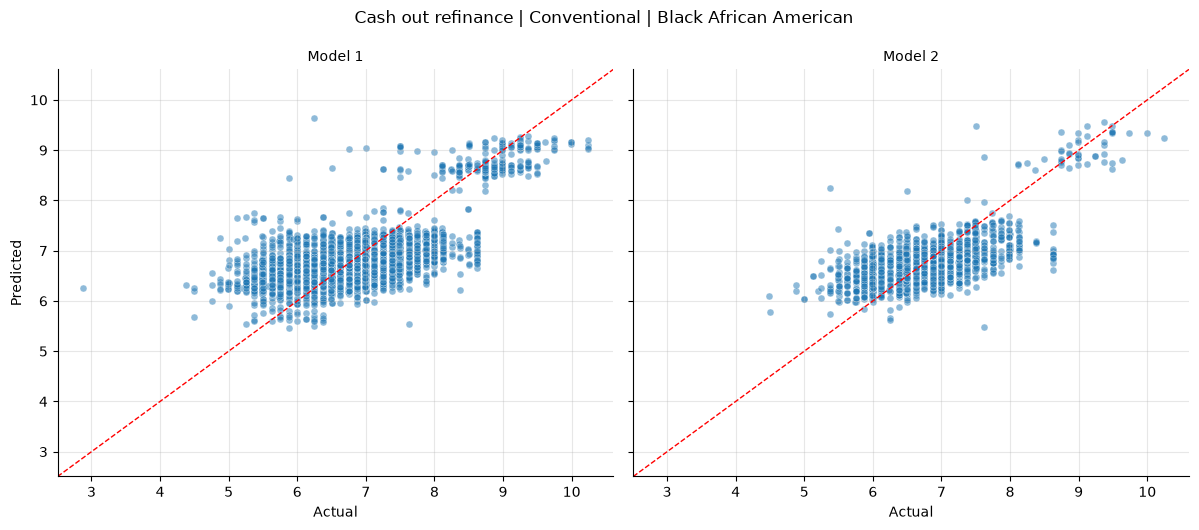

Female
(12230, 7)


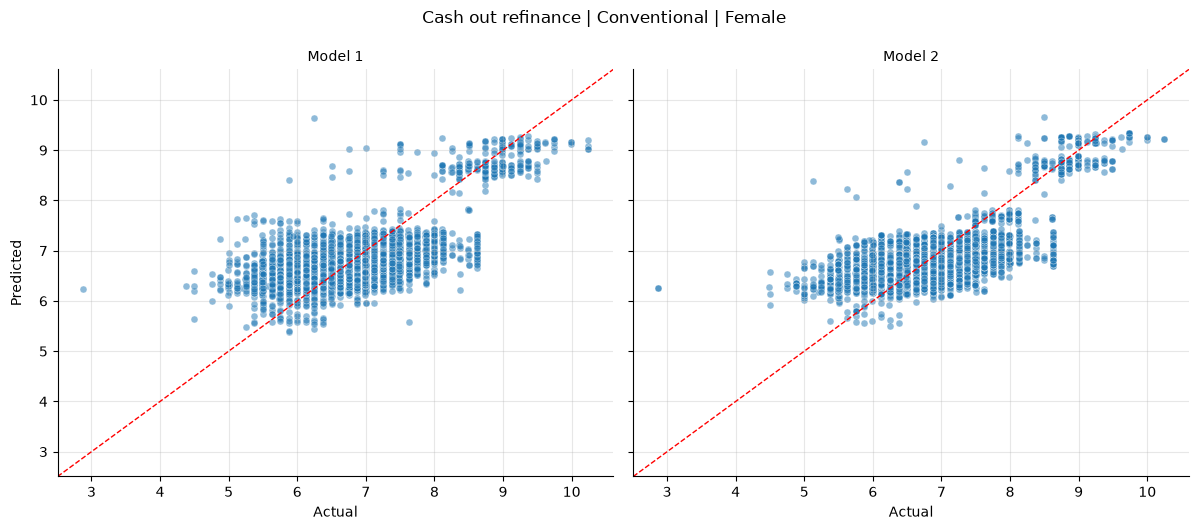

Yes
(11906, 7)


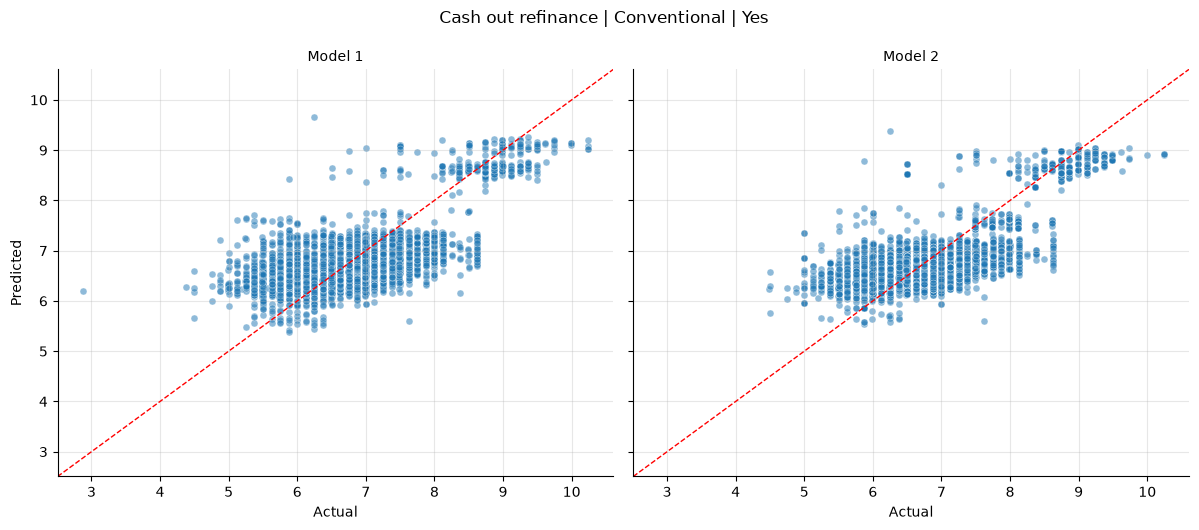

FHA insured
Female
(611, 7)


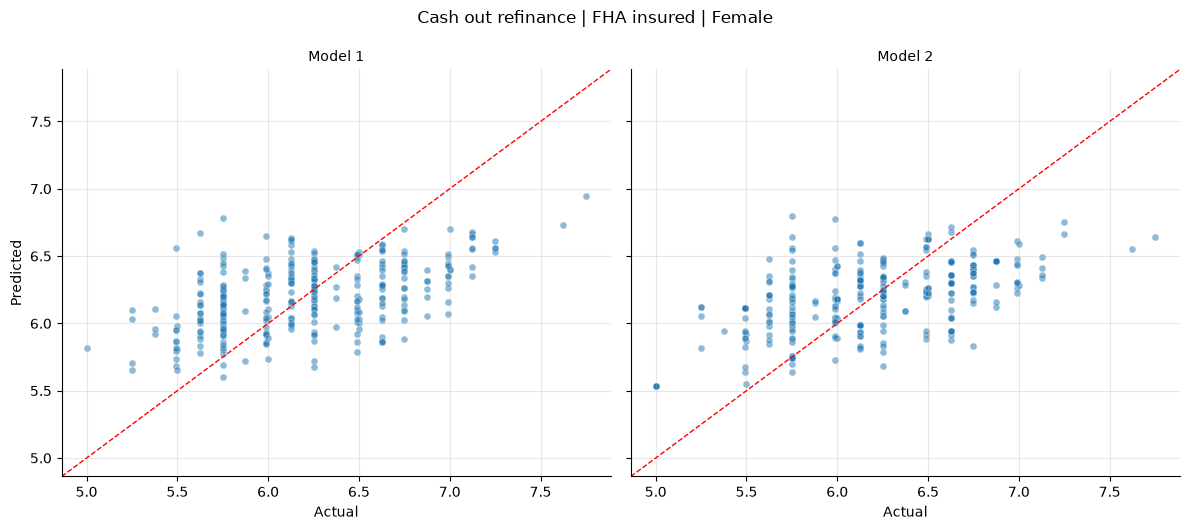


Home purchase
Conventional
Black African American
(24476, 7)


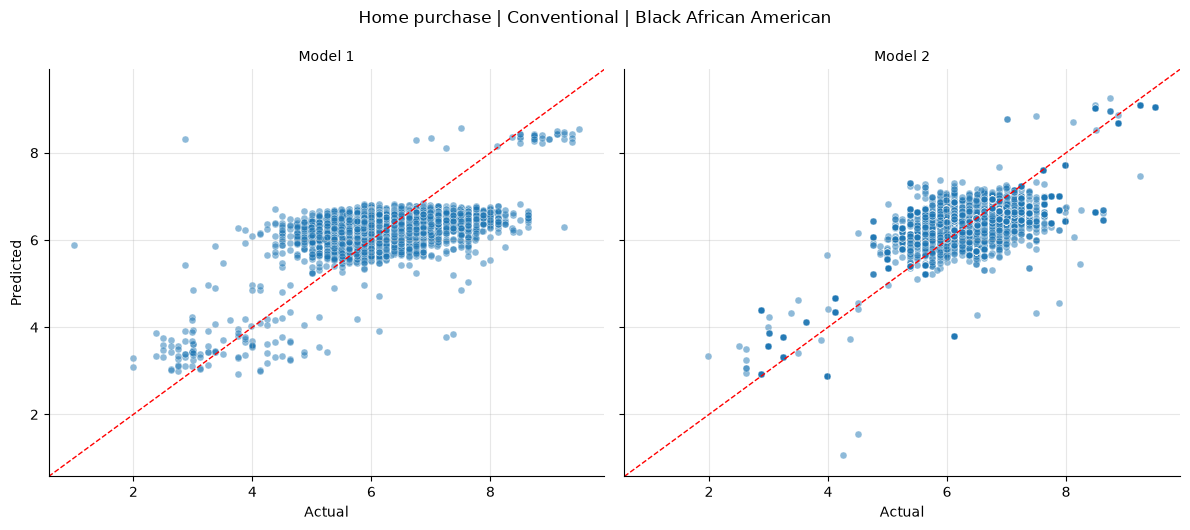

Female
(45470, 7)


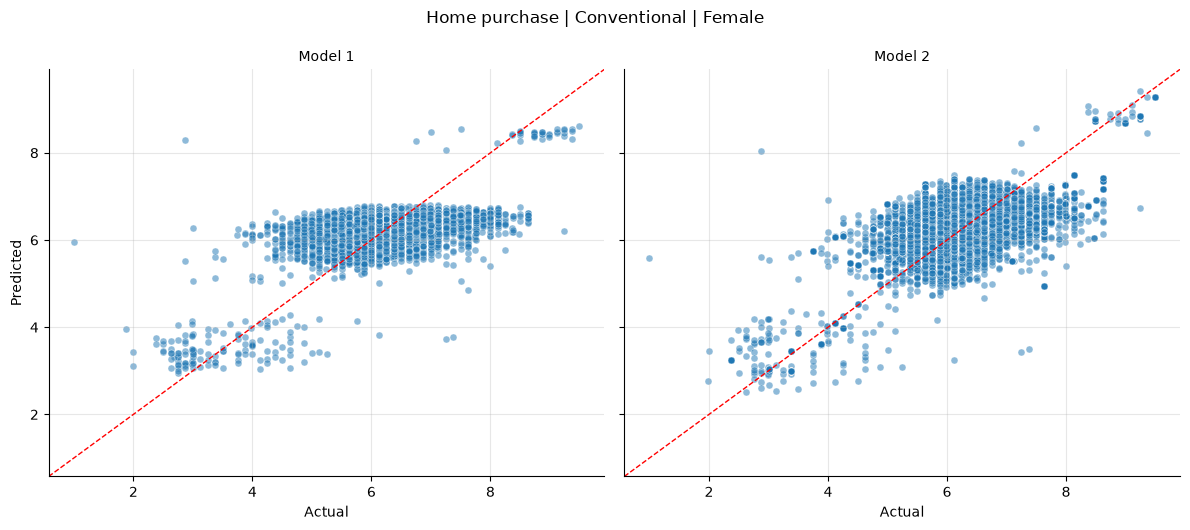

Yes
(32254, 7)


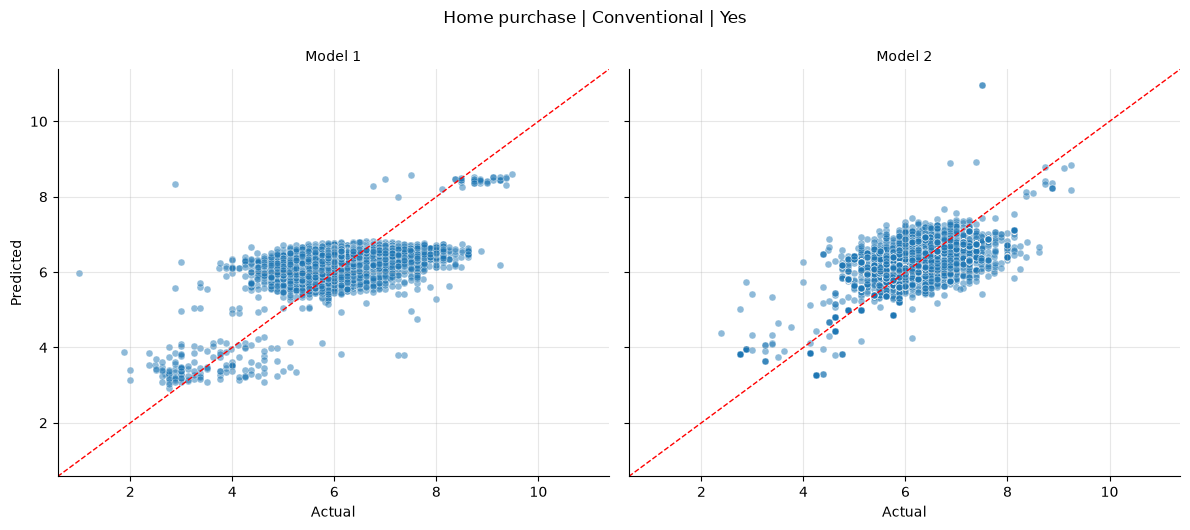

FHA insured
Black African American
(919, 7)


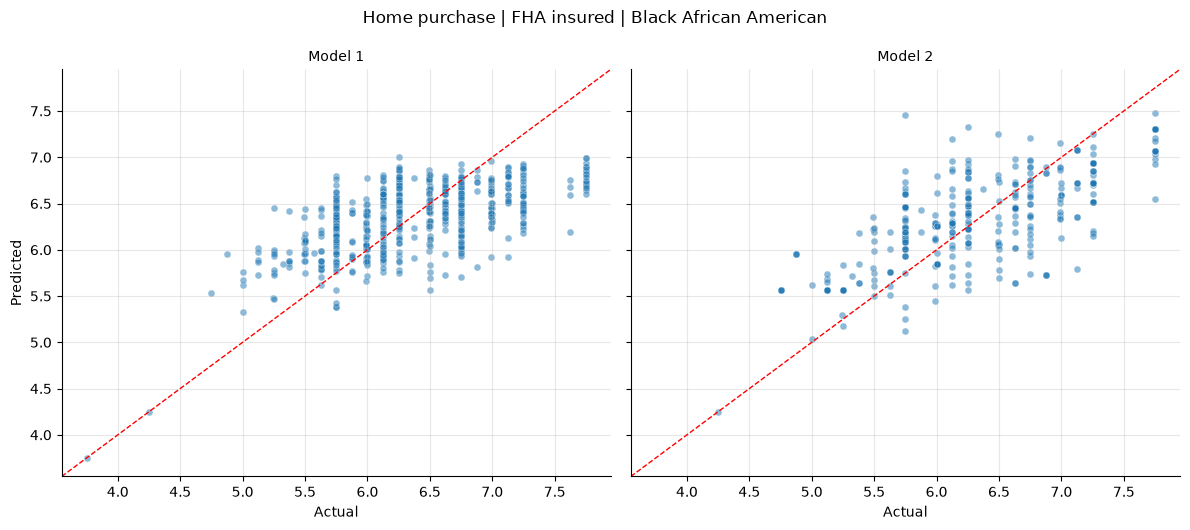

Female
(1158, 7)


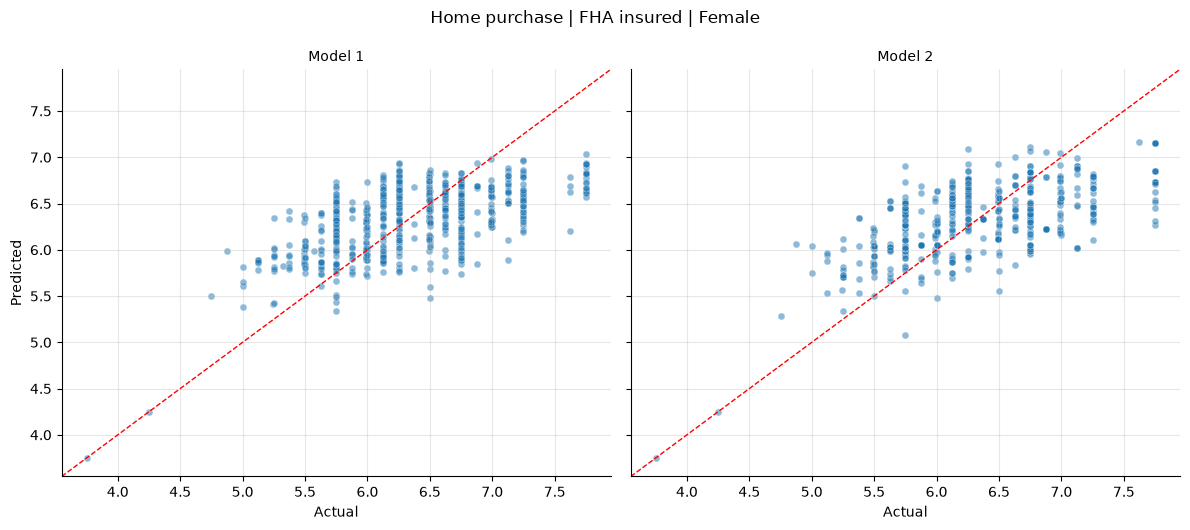


Home improvement
Conventional
Female
(3995, 7)


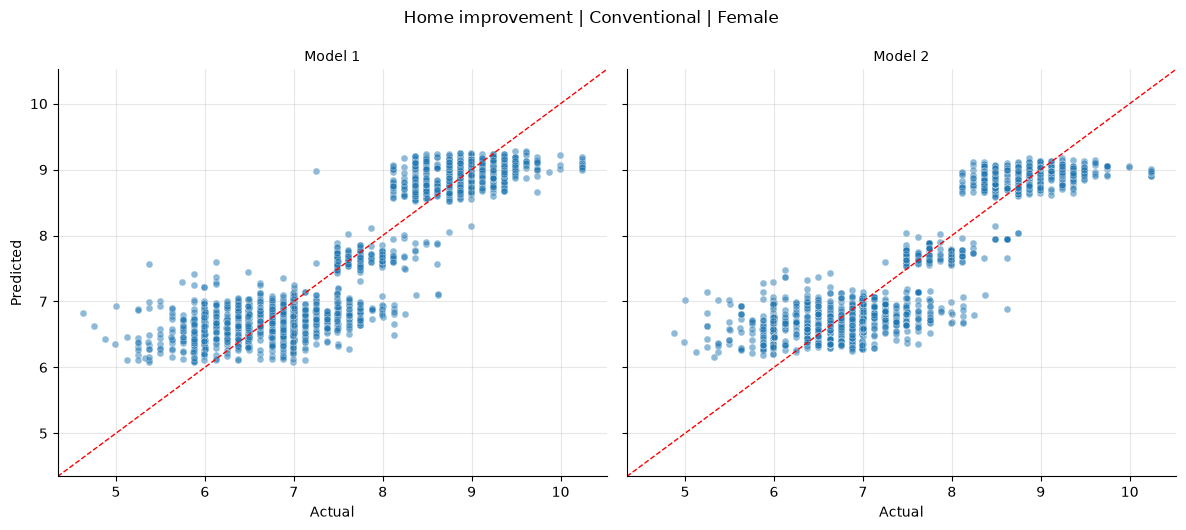

Yes
(3841, 7)


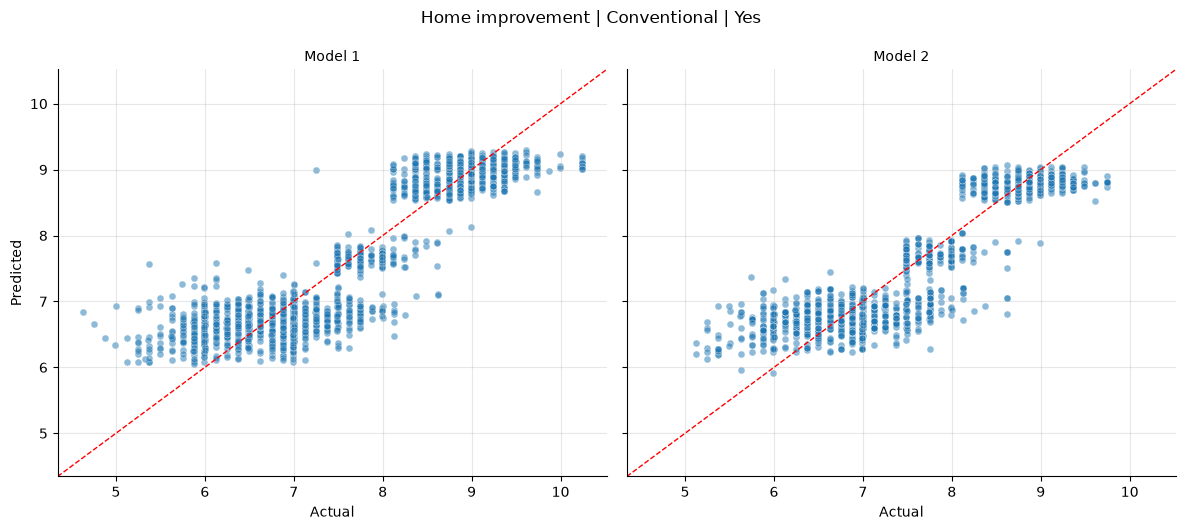


Refinance
Conventional
Female
(10652, 7)


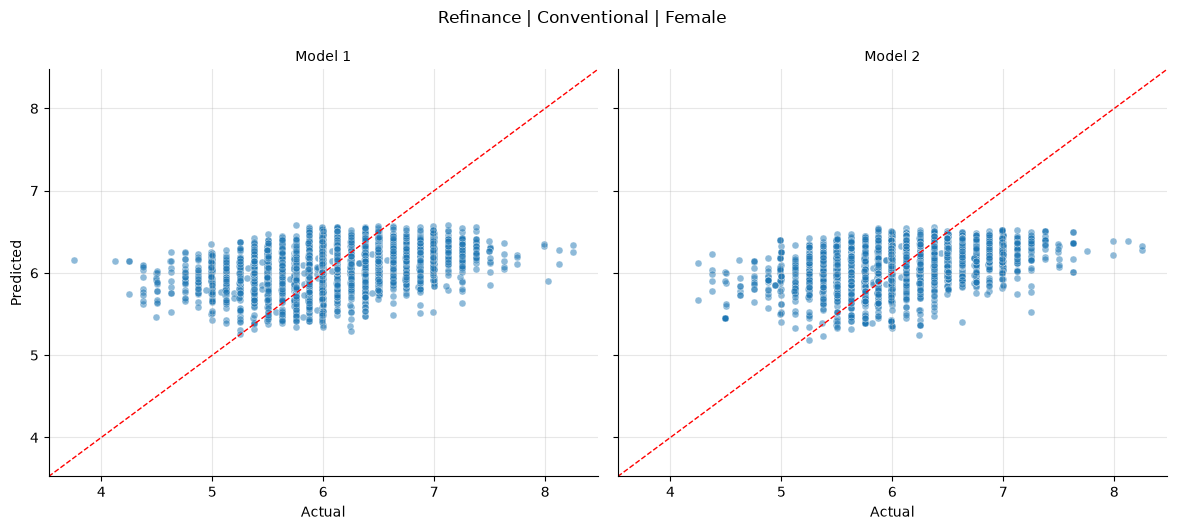

Yes
(8347, 7)


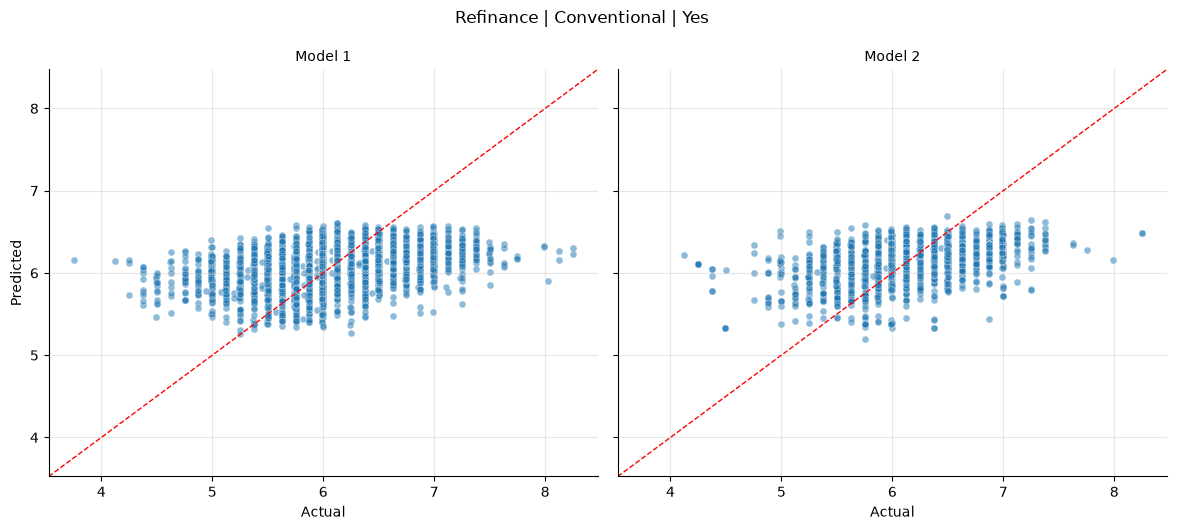

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only the models of interest
pred_summary = pred_summary[
    pred_summary["model"].isin(["Model 1", "Model 2"])
].copy()

for purp_j in pred_summary["loan purpose"].dropna().unique():
    print(f"\n{purp_j}")

    for type_j in pred_summary.loc[
        pred_summary["loan purpose"] == purp_j,
        "loan type"
    ].dropna().unique():

        print(type_j)

        for pb_j in pred_summary.loc[
            (pred_summary["loan purpose"] == purp_j)
            & (pred_summary["loan type"] == type_j),
            "protected basis"
        ].dropna().unique():

            print(pb_j)

            # Select both models and use the price step
            pred_ = pred_summary[
                (pred_summary["loan purpose"] == purp_j)
                & (pred_summary["loan type"] == type_j)
                & (pred_summary["step"] == "price")
                & (pred_summary["protected basis"] == pb_j)
                & (pred_summary["model"].isin(["Model 1", "Model 2"]))
            ].dropna(subset=["actual", "prediction"])

            print(pred_.shape)

            # Create side-by-side plots for Model 1 and Model 2
            g = sns.FacetGrid(
                pred_,
                col="model",
                col_order=["Model 1", "Model 2"],
                height=5,
                aspect=1.2,
                sharex=True,
                sharey=True
            )

            g.map_dataframe(
                sns.scatterplot,
                x="actual",
                y="prediction",
                alpha=0.5,
                s=25
            )

            # Add a 45-degree reference line to each subplot
            for ax in g.axes.flat:
                x_limits = ax.get_xlim()
                y_limits = ax.get_ylim()

                lower = min(x_limits[0], y_limits[0])
                upper = max(x_limits[1], y_limits[1])

                ax.plot(
                    [lower, upper],
                    [lower, upper],
                    linestyle="--",
                    color="red",
                    linewidth=1
                )

                ax.set_xlim(lower, upper)
                ax.set_ylim(lower, upper)

                ax.set_xlabel("Actual")
                ax.set_ylabel("Predicted")
                ax.grid(alpha=0.3)

            g.set_titles("{col_name}")

            g.figure.suptitle(
                f"{purp_j} | {type_j} | {pb_j}",
                y=1.05
            )

            plt.show()
